# 4Cv5 — 4Av5 input-to-ESN dynamics correspondence analysis

This notebook is the dynamics companion to 4Av5/4Bv5. Following the analysis structure of
Notebook 7, it aligns the physical inputs and reservoir trajectories at the trial, material,
temperature, and repetition levels. It loads the optimized shared 4Av5 reservoir but performs
**no optimization and no regression**.

The exact ESN inputs are the absolute Savitzky–Golay-smoothed primary signal `P` and its first
derivative `dP/dt`. No secondary signal, baseline centering, min–max transform, or fitted input
scaler is used.

# 1. Imports and analysis configuration

In [1]:
from pathlib import Path
import json
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import linalg
from scipy.signal import savgol_filter

plt.rcParams.update({"figure.dpi": 120, "axes.grid": True, "grid.alpha": 0.20})

TEMPERATURE_FOLDERS = ("30C", "40C", "50C", "60C")
ANALYSIS_WINDOW = (0.0, 3.0)

# Notebook-7-style display controls.
SELECTED_MATERIAL = "graphite"
SELECTED_TEMPERATURE = "60C"
CASE_STUDY_MATERIALS = ("gypsum", "wood", "pdms", "cement")
REPETITION_MATERIAL = SELECTED_MATERIAL
REPETITION_TEMPERATURE = SELECTED_TEMPERATURE
DISPLAY_SEED = 42
MAXIMUM_DISPLAY_UNITS = 6
GROUP_RANDOM_UNIT_COUNT = 6
GRID_POINTS = 101

cwd = Path.cwd().resolve()
PROJECT_ROOT = next((p for p in (cwd, cwd.parent) if (p / "data").is_dir()), None)
if PROJECT_ROOT is None:
    raise FileNotFoundError("Run from the project root or notebooks directory.")
DATA_ROOT = PROJECT_ROOT / "data" / "02_preprocessed"
RESULTS_DIR = PROJECT_ROOT / "results" / "multi_temp_esn"
DIAGNOSTIC_DIR = PROJECT_ROOT / "results" / "input_esn_dynamics_4cv5"
DIAGNOSTIC_DIR.mkdir(parents=True, exist_ok=True)

temperature_tag = "-".join(TEMPERATURE_FOLDERS)
PARAMETER_FILE = RESULTS_DIR / (
    f"{temperature_tag}_eff_4av5_primary_dprimary_absolute_smoothed_0to3_"
    "summarized_esn_thermal_optuna_tpe_mlflow_parameters.json"
)
RESULT_STEM = f"{temperature_tag}_eff_4cv5_primary_dprimary_input_to_esn_dynamics"
if not PARAMETER_FILE.is_file():
    raise FileNotFoundError(
        f"Missing revised 4Av5 parameter file:\n{PARAMETER_FILE}\nRun 4Av5 first."
    )
with PARAMETER_FILE.open() as file:
    CONFIG = json.load(file)
if CONFIG.get("esn_input_channels") != ["Primary", "dPrimary/dt"]:
    raise ValueError("The parameter JSON is not the revised P + dP/dt 4Av5 configuration.")
if not np.allclose(CONFIG["analysis_window"], ANALYSIS_WINDOW):
    raise ValueError("4Cv5 requires the same 0–3 s window used by 4Av5.")

ESN_PARAMS = CONFIG["esn_parameters"]
RESERVOIR_SEEDS = tuple(int(x) for x in CONFIG["reservoir_seeds"])
if DISPLAY_SEED not in RESERVOIR_SEEDS:
    warnings.warn(f"DISPLAY_SEED={DISPLAY_SEED} is not one of {RESERVOIR_SEEDS}.")
print("Loaded:", PARAMETER_FILE)
print("Exact ESN input: absolute smoothed P + dP/dt; no input scaling")
print("ESN parameters:", ESN_PARAMS)
print("Reservoir seeds:", RESERVOIR_SEEDS)

Loaded: /Users/markkeanujamesexconde/Library/CloudStorage/OneDrive-Personal/Documents/Academe Files/4. Doctoral/Research 1 - Warmth Sensor/Warmth-Sensor-Object-Detection/results/multi_temp_esn/30C-40C-50C-60C_eff_4av5_primary_dprimary_absolute_smoothed_0to3_summarized_esn_thermal_optuna_tpe_mlflow_parameters.json
Exact ESN input: absolute smoothed P + dP/dt; no input scaling
ESN parameters: {'res_size': 10, 'leak_rate': 0.6946377960167112, 'input_magnitude': 1.6495680356466318, 'spectral_radius': 0.7604674118595436, 'washout': 0}
Reservoir seeds: (42, 43, 44)


## Interpretation safeguard

The displayed state curves are diagnostics of the fixed reservoir transformation. Similar-looking
representative units do not prove that complete reservoir representations are identical; all-unit
heatmaps and quantitative distances below assess the full state space.

# 2. Load processed trials and align contact

In [2]:
SAMPLE_ALIASES = {
    "ps": "ps_foam", "ps foam": "ps_foam", "ps_foam": "ps_foam",
    "pu": "pu_foam", "pu foam": "pu_foam", "pu_foam": "pu_foam",
    "cork": "cork", "cork fine": "cork", "cork_fine": "cork",
    "wood": "wood", "pdms": "pdms", "gypsum": "gypsum", "cement": "cement",
    "graphite": "graphite", "carbon": "graphite", "bi": "bismuth",
    "bismuth": "bismuth", "ti": "titanium", "titanium": "titanium",
    "ni": "nickel", "nickel": "nickel", "fe": "iron", "iron": "iron",
    "al": "aluminum", "aluminum": "aluminum", "cu": "copper", "copper": "copper",
}
required = {"Sample", "Trial", "Time", "Primary"}
frames = []
for temperature in TEMPERATURE_FOLDERS:
    for path in sorted((DATA_ROOT / temperature).glob("*.csv")):
        frame = pd.read_csv(path)
        if not required.issubset(frame.columns):
            warnings.warn(f"Skipping {path}: missing required columns")
            continue
        frame["Temperature"] = temperature
        frames.append(frame)
if not frames:
    raise ValueError("No compatible processed trials were found.")

DATA = pd.concat(frames, ignore_index=True).replace([np.inf, -np.inf], np.nan)
for column in ("Trial", "Time", "Primary"):
    DATA[column] = pd.to_numeric(DATA[column], errors="coerce")
DATA = DATA.dropna(subset=list(required) + ["Temperature"]).copy()
DATA["Trial"] = DATA["Trial"].astype(int)
normalized = DATA["Sample"].astype(str).str.strip().str.lower().str.replace("_", " ")
DATA["Sample"] = normalized.map(SAMPLE_ALIASES)
if DATA["Sample"].isna().any():
    raise KeyError(f"Unknown materials: {sorted(normalized[DATA['Sample'].isna()].unique())}")
DATA["trial_id"] = (
    DATA["Temperature"] + "__" + DATA["Sample"] + "_trial_" + DATA["Trial"].astype(str)
)

def find_contact_time(trial, smooth_window=15, polyorder=2, threshold_frac=0.30, skip_samples=5):
    clean = trial[["Time", "Primary"]].dropna().sort_values("Time").drop_duplicates("Time")
    time = clean["Time"].to_numpy(float)
    signal = clean["Primary"].to_numpy(float)
    if len(signal) < skip_samples + 7 or np.any(np.diff(time) <= 0):
        raise ValueError("Insufficient or invalid samples.")
    time, signal = time[skip_samples:], signal[skip_samples:]
    window = min(smooth_window, len(signal)); window -= (window % 2 == 0)
    smooth = savgol_filter(signal, window, polyorder, mode="interp")
    derivative = np.gradient(smooth, time)
    strongest = int(np.argmin(derivative))
    active = derivative < threshold_frac * derivative[strongest]
    elbow = 0
    for position in range(strongest, -1, -1):
        if not active[position]:
            elbow = position + 1
            break
    return float(time[elbow])

aligned_trials, metadata_rows = {}, []
for trial_id, trial in DATA.groupby("trial_id", sort=False):
    trial = trial.sort_values("Time").drop_duplicates("Time").copy()
    try:
        contact = find_contact_time(trial)
    except ValueError as exc:
        warnings.warn(f"Skipping {trial_id}: {exc}")
        continue
    trial["time_from_contact"] = trial["Time"] - contact
    trial = trial[trial["time_from_contact"].between(*ANALYSIS_WINDOW)].copy()
    if len(trial) < 10:
        continue
    aligned_trials[trial_id] = trial.reset_index(drop=True)
    metadata_rows.append({
        "trial_id": trial_id, "Sample": trial["Sample"].iloc[0],
        "Temperature": trial["Temperature"].iloc[0], "Trial": int(trial["Trial"].iloc[0]),
    })
METADATA = pd.DataFrame(metadata_rows)
available_samples = sorted(METADATA["Sample"].unique())
unknown = sorted(set(CASE_STUDY_MATERIALS) - set(available_samples))
if unknown:
    raise KeyError(f"Unknown CASE_STUDY_MATERIALS: {unknown}")
if SELECTED_MATERIAL not in available_samples:
    raise KeyError(f"Unknown SELECTED_MATERIAL={SELECTED_MATERIAL!r}")
print("Aligned trials:", len(METADATA), "| materials:", len(available_samples))
display(METADATA.groupby("Temperature").agg(trials=("trial_id", "size"), materials=("Sample", "nunique")))

Aligned trials: 336 | materials: 14


,trials,materials
Temperature,,
30C,84,14
40C,84,14
50C,84,14
60C,84,14


# 3. Reconstruct the exact fixed 4Av5 reservoir dynamics

In [3]:
def smooth_primary(trial, window=11, polyorder=2):
    values = trial["Primary"].to_numpy(float)
    selected = min(window, len(values)); selected -= (selected % 2 == 0)
    return savgol_filter(values, selected, polyorder, mode="interp") if selected >= 5 else values.copy()

def raw_esn_input(trial):
    time = trial["time_from_contact"].to_numpy(float)
    primary = smooth_primary(trial)
    return np.column_stack([primary, np.gradient(primary, time)])

class ManualReservoir:
    def __init__(self, params, random_state):
        self.res_size = int(params["res_size"])
        self.leak_rate = float(params["leak_rate"])
        self.washout = int(params["washout"])
        rng = np.random.default_rng(random_state)
        self.Win = (rng.random((self.res_size, 3)) - 0.5) * float(params["input_magnitude"])
        W = rng.random((self.res_size, self.res_size)) - 0.5
        radius = np.max(np.abs(linalg.eigvals(W)))
        if not np.isfinite(radius) or np.isclose(radius, 0):
            raise ValueError("Invalid recurrent matrix spectral radius.")
        self.W = (W / radius.real) * float(params["spectral_radius"])

    def run(self, sequence):
        sequence = np.asarray(sequence, float)
        if sequence.ndim != 2 or sequence.shape[1] != 2:
            raise ValueError("Expected P and dP/dt.")
        x = np.zeros((self.res_size, 1)); states = []
        for row in sequence:
            proposed = np.tanh(self.Win @ np.r_[1.0, row].reshape(-1, 1) + self.W @ x)
            x = (1 - self.leak_rate) * x + self.leak_rate * proposed
            states.append(x[:, 0].copy())
        return np.asarray(states)[self.washout:]

TIME_GRID = np.linspace(*ANALYSIS_WINDOW, GRID_POINTS)
STATE_TIME_GRID = TIME_GRID.copy()
REPRESENTATIVE_UNITS = np.unique(np.linspace(
    0, int(ESN_PARAMS["res_size"]) - 1,
    min(MAXIMUM_DISPLAY_UNITS, int(ESN_PARAMS["res_size"])), dtype=int,
))
_DIAGNOSTIC_CACHE = {}

def interpolate_columns(old_time, matrix, new_time):
    matrix = np.asarray(matrix, float)
    return np.column_stack([
        np.interp(new_time, old_time, matrix[:, column], left=np.nan, right=np.nan)
        for column in range(matrix.shape[1])
    ])

def trial_diagnostics(trial_id, seed=DISPLAY_SEED):
    key = (trial_id, int(seed))
    if key not in _DIAGNOSTIC_CACHE:
        trial = aligned_trials[trial_id]
        time = trial["time_from_contact"].to_numpy(float)
        inputs = raw_esn_input(trial)
        states = ManualReservoir(ESN_PARAMS, seed).run(inputs)
        state_time = time[int(ESN_PARAMS["washout"]):]
        _DIAGNOSTIC_CACHE[key] = {
            "inputs": interpolate_columns(time, inputs, TIME_GRID),
            "states": interpolate_columns(state_time, states, STATE_TIME_GRID),
        }
    return _DIAGNOSTIC_CACHE[key]

def mean_and_sd(arrays):
    array = np.stack(arrays)
    return np.nanmean(array, axis=0), (
        np.nanstd(array, axis=0, ddof=1) if len(array) > 1 else np.zeros(array.shape[1:])
    )

print("Representative units:", REPRESENTATIVE_UNITS.tolist())
audit = raw_esn_input(aligned_trials[METADATA["trial_id"].iloc[0]])
assert audit.shape[1] == 2
print("Input audit passed:", audit.shape, "columns = [P, dP/dt]")

Representative units: [0, 1, 3, 5, 7, 9]
Input audit passed: (30, 2) columns = [P, dP/dt]


# 4. Notebook-7-style aligned correspondence plots

In [4]:
def make_block(label, trial_ids, seed=DISPLAY_SEED):
    if not trial_ids:
        raise ValueError(f"No trials for {label}")
    payloads = [trial_diagnostics(trial_id, seed) for trial_id in trial_ids]
    input_mean, input_sd = mean_and_sd([x["inputs"] for x in payloads])
    state_mean, state_sd = mean_and_sd([x["states"] for x in payloads])
    rms_trials = [np.sqrt(np.nanmean(x["states"] ** 2, axis=1)) for x in payloads]
    rms_mean, rms_sd = mean_and_sd(rms_trials)
    return {
        "label": label, "trial_ids": list(trial_ids), "n": len(trial_ids),
        "input_mean": input_mean, "input_sd": input_sd,
        "state_mean": state_mean, "state_sd": state_sd,
        "rms_mean": rms_mean, "rms_sd": rms_sd,
    }

def save_figure(fig, filename):
    output = DIAGNOSTIC_DIR / filename
    fig.savefig(output, dpi=220, bbox_inches="tight")
    plt.show()
    print("Saved:", output)
    return output

def plot_input_state_correspondence(blocks, title, output_name):
    block_width = ANALYSIS_WINDOW[1] - ANALYSIS_WINDOW[0]
    gap = 0.35
    fig, axes = plt.subplots(3, 1, figsize=(16, 10.5), sharex=True)
    ax_p, ax_dp, ax_state = axes
    unit_colors = plt.cm.tab10(np.linspace(0, 1, len(REPRESENTATIVE_UNITS)))
    centers, boundaries = [], []
    for block_index, block in enumerate(blocks):
        offset = block_index * (block_width + gap)
        x = offset + TIME_GRID
        xs = offset + STATE_TIME_GRID
        centers.append(offset + block_width / 2)
        boundaries.append(offset + block_width + gap / 2)
        for axis, column, color in ((ax_p, 0, "tab:blue"), (ax_dp, 1, "tab:cyan")):
            mean, sd = block["input_mean"][:, column], block["input_sd"][:, column]
            axis.plot(x, mean, color=color, linewidth=1.7)
            axis.fill_between(x, mean - sd, mean + sd, color=color, alpha=0.14)
        for color, unit in zip(unit_colors, REPRESENTATIVE_UNITS):
            mean, sd = block["state_mean"][:, unit], block["state_sd"][:, unit]
            ax_state.plot(xs, mean, color=color, linewidth=1.15,
                          label=f"Unit {unit}" if block_index == 0 else None)
            ax_state.fill_between(xs, mean - sd, mean + sd, color=color, alpha=0.06)
    for boundary in boundaries[:-1]:
        for axis in axes:
            axis.axvline(boundary, color="red", linestyle="--", linewidth=1.0, alpha=0.70)
    ax_p.set_ylabel("Absolute P")
    ax_p.set_title("Absolute smoothed primary input: repetition mean ± SD")
    ax_dp.set_ylabel("dP/dt")
    ax_dp.set_title("Primary first derivative: repetition mean ± SD")
    ax_state.set_ylabel("Activation")
    ax_state.set_title(f"Representative ESN trajectories: seed={DISPLAY_SEED}")
    ax_state.legend(ncol=3, fontsize=8)
    ax_state.set_xticks(centers, [f"{b['label']}\n(n={b['n']})" for b in blocks])
    ax_state.set_xlabel("Independent 0–3 s trial blocks")
    fig.suptitle(title, fontsize=15)
    fig.tight_layout(rect=(0, 0, 1, 0.97))
    return save_figure(fig, output_name)

# 5. Detailed case study — selected materials at one temperature

This is the direct counterpart of Notebook 7's selected-material correspondence figure. The same
unit indices, reservoir seed, hyperparameters, and time grid are used in every material block.

/Users/markkeanujamesexconde/.virtualenvs/warmth-sensor-object-detection/lib/python3.13/site-packages/numpy/lib/_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/var/folders/fx/p7h99klx61g3f9j63ld4_xcm0000gn/T/ipykernel_24228/4032576448.py:7: RuntimeWarning: Mean of empty slice
  rms_trials = [np.sqrt(np.nanmean(x["states"] ** 2, axis=1)) for x in payloads]


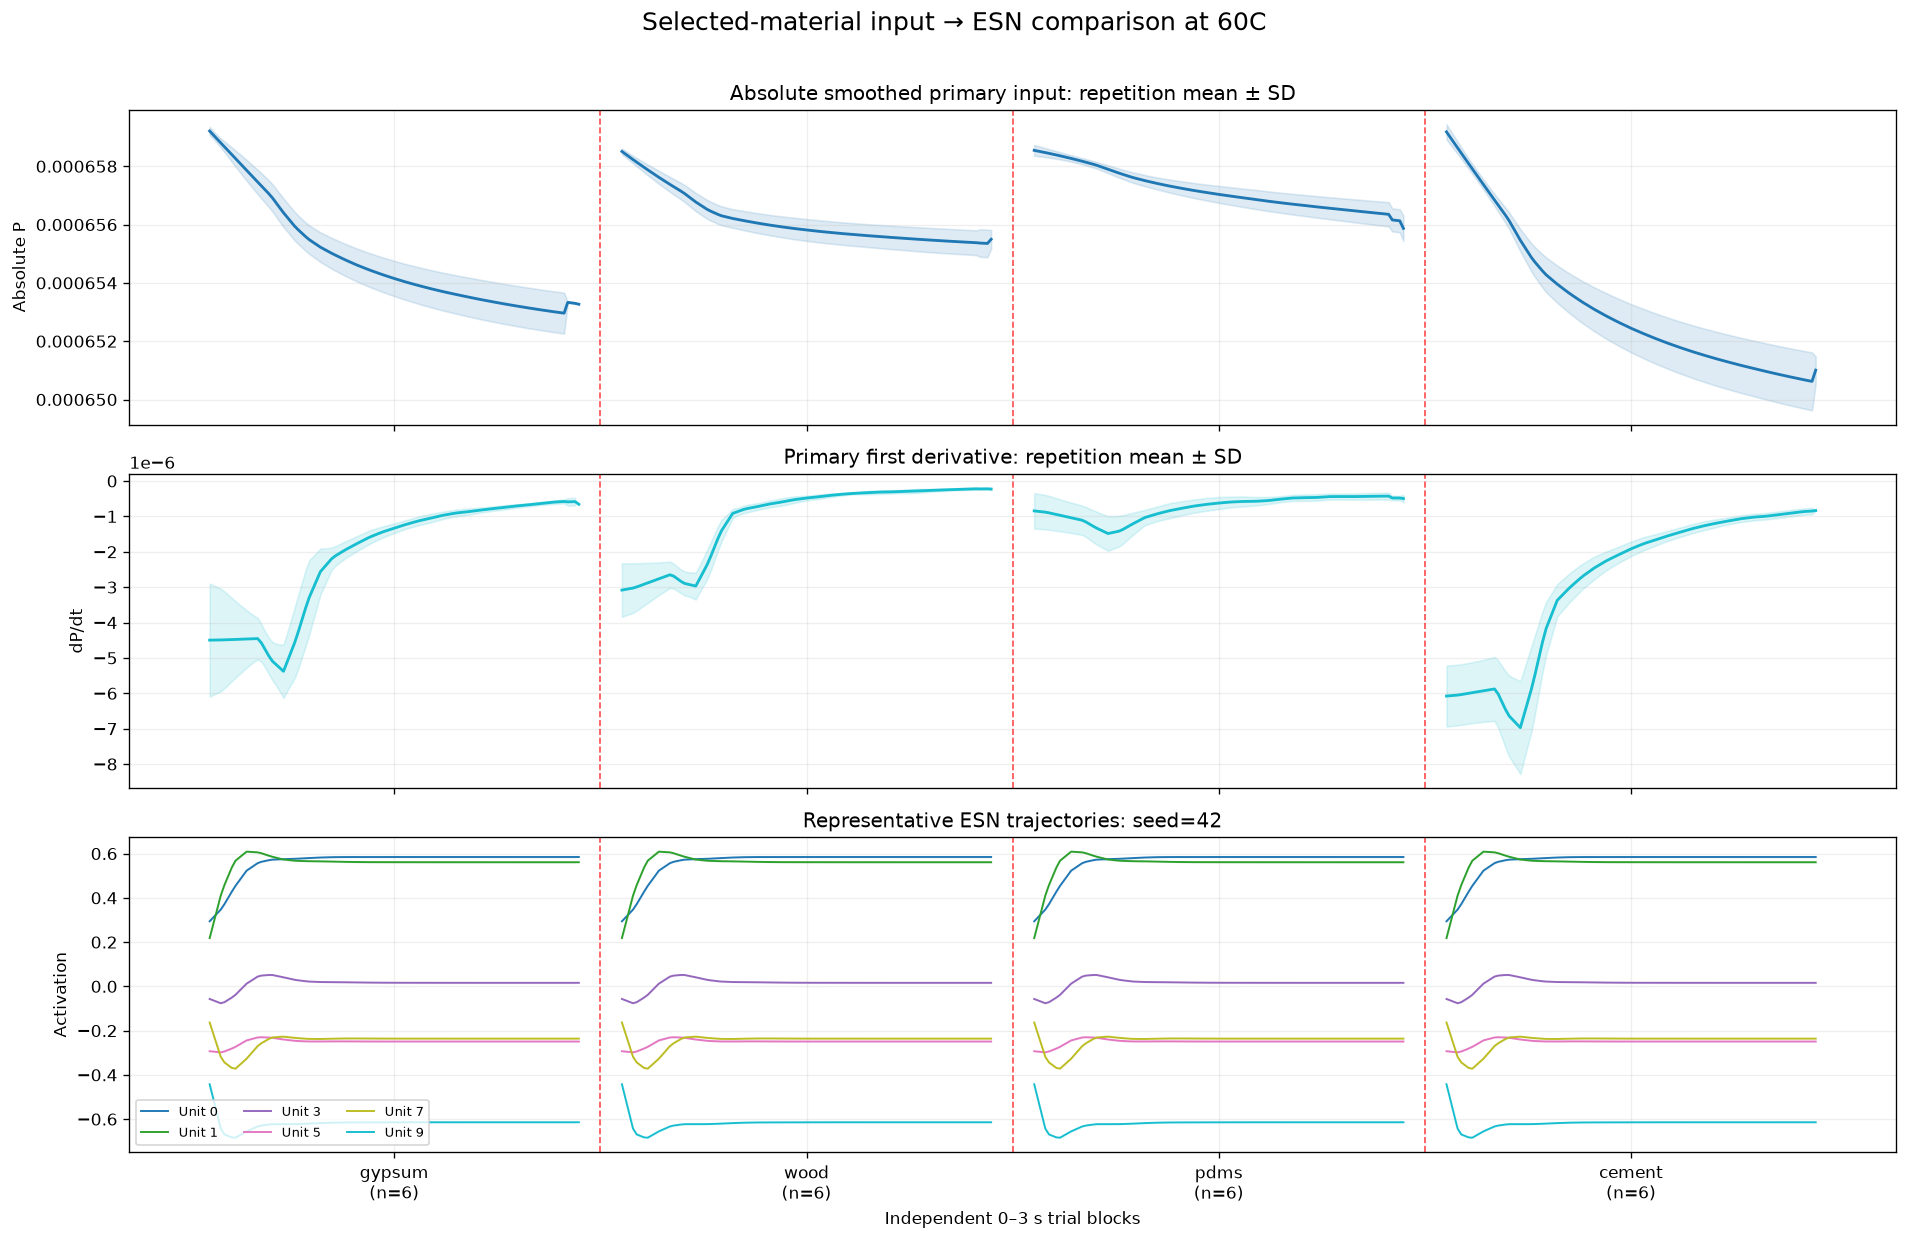

Saved: /Users/markkeanujamesexconde/Library/CloudStorage/OneDrive-Personal/Documents/Academe Files/4. Doctoral/Research 1 - Warmth Sensor/Warmth-Sensor-Object-Detection/results/input_esn_dynamics_4cv5/selected_material_input_esn_60C.png


In [5]:
material_blocks = []
for material in CASE_STUDY_MATERIALS:
    ids = METADATA.loc[
        (METADATA["Sample"] == material) & (METADATA["Temperature"] == SELECTED_TEMPERATURE),
        "trial_id",
    ].tolist()
    material_blocks.append(make_block(material, ids))
CASE_STUDY_FIGURE = plot_input_state_correspondence(
    material_blocks,
    f"Selected-material input → ESN comparison at {SELECTED_TEMPERATURE}",
    f"selected_material_input_esn_{SELECTED_TEMPERATURE}.png",
)

# 6. All materials grouped by effusivity

/var/folders/fx/p7h99klx61g3f9j63ld4_xcm0000gn/T/ipykernel_24228/4032576448.py:7: RuntimeWarning: Mean of empty slice
  rms_trials = [np.sqrt(np.nanmean(x["states"] ** 2, axis=1)) for x in payloads]
/Users/markkeanujamesexconde/.virtualenvs/warmth-sensor-object-detection/lib/python3.13/site-packages/numpy/lib/_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/var/folders/fx/p7h99klx61g3f9j63ld4_xcm0000gn/T/ipykernel_24228/1989336205.py:66: RuntimeWarning: Mean of empty slice
  return np.nanmean(array, axis=0), (


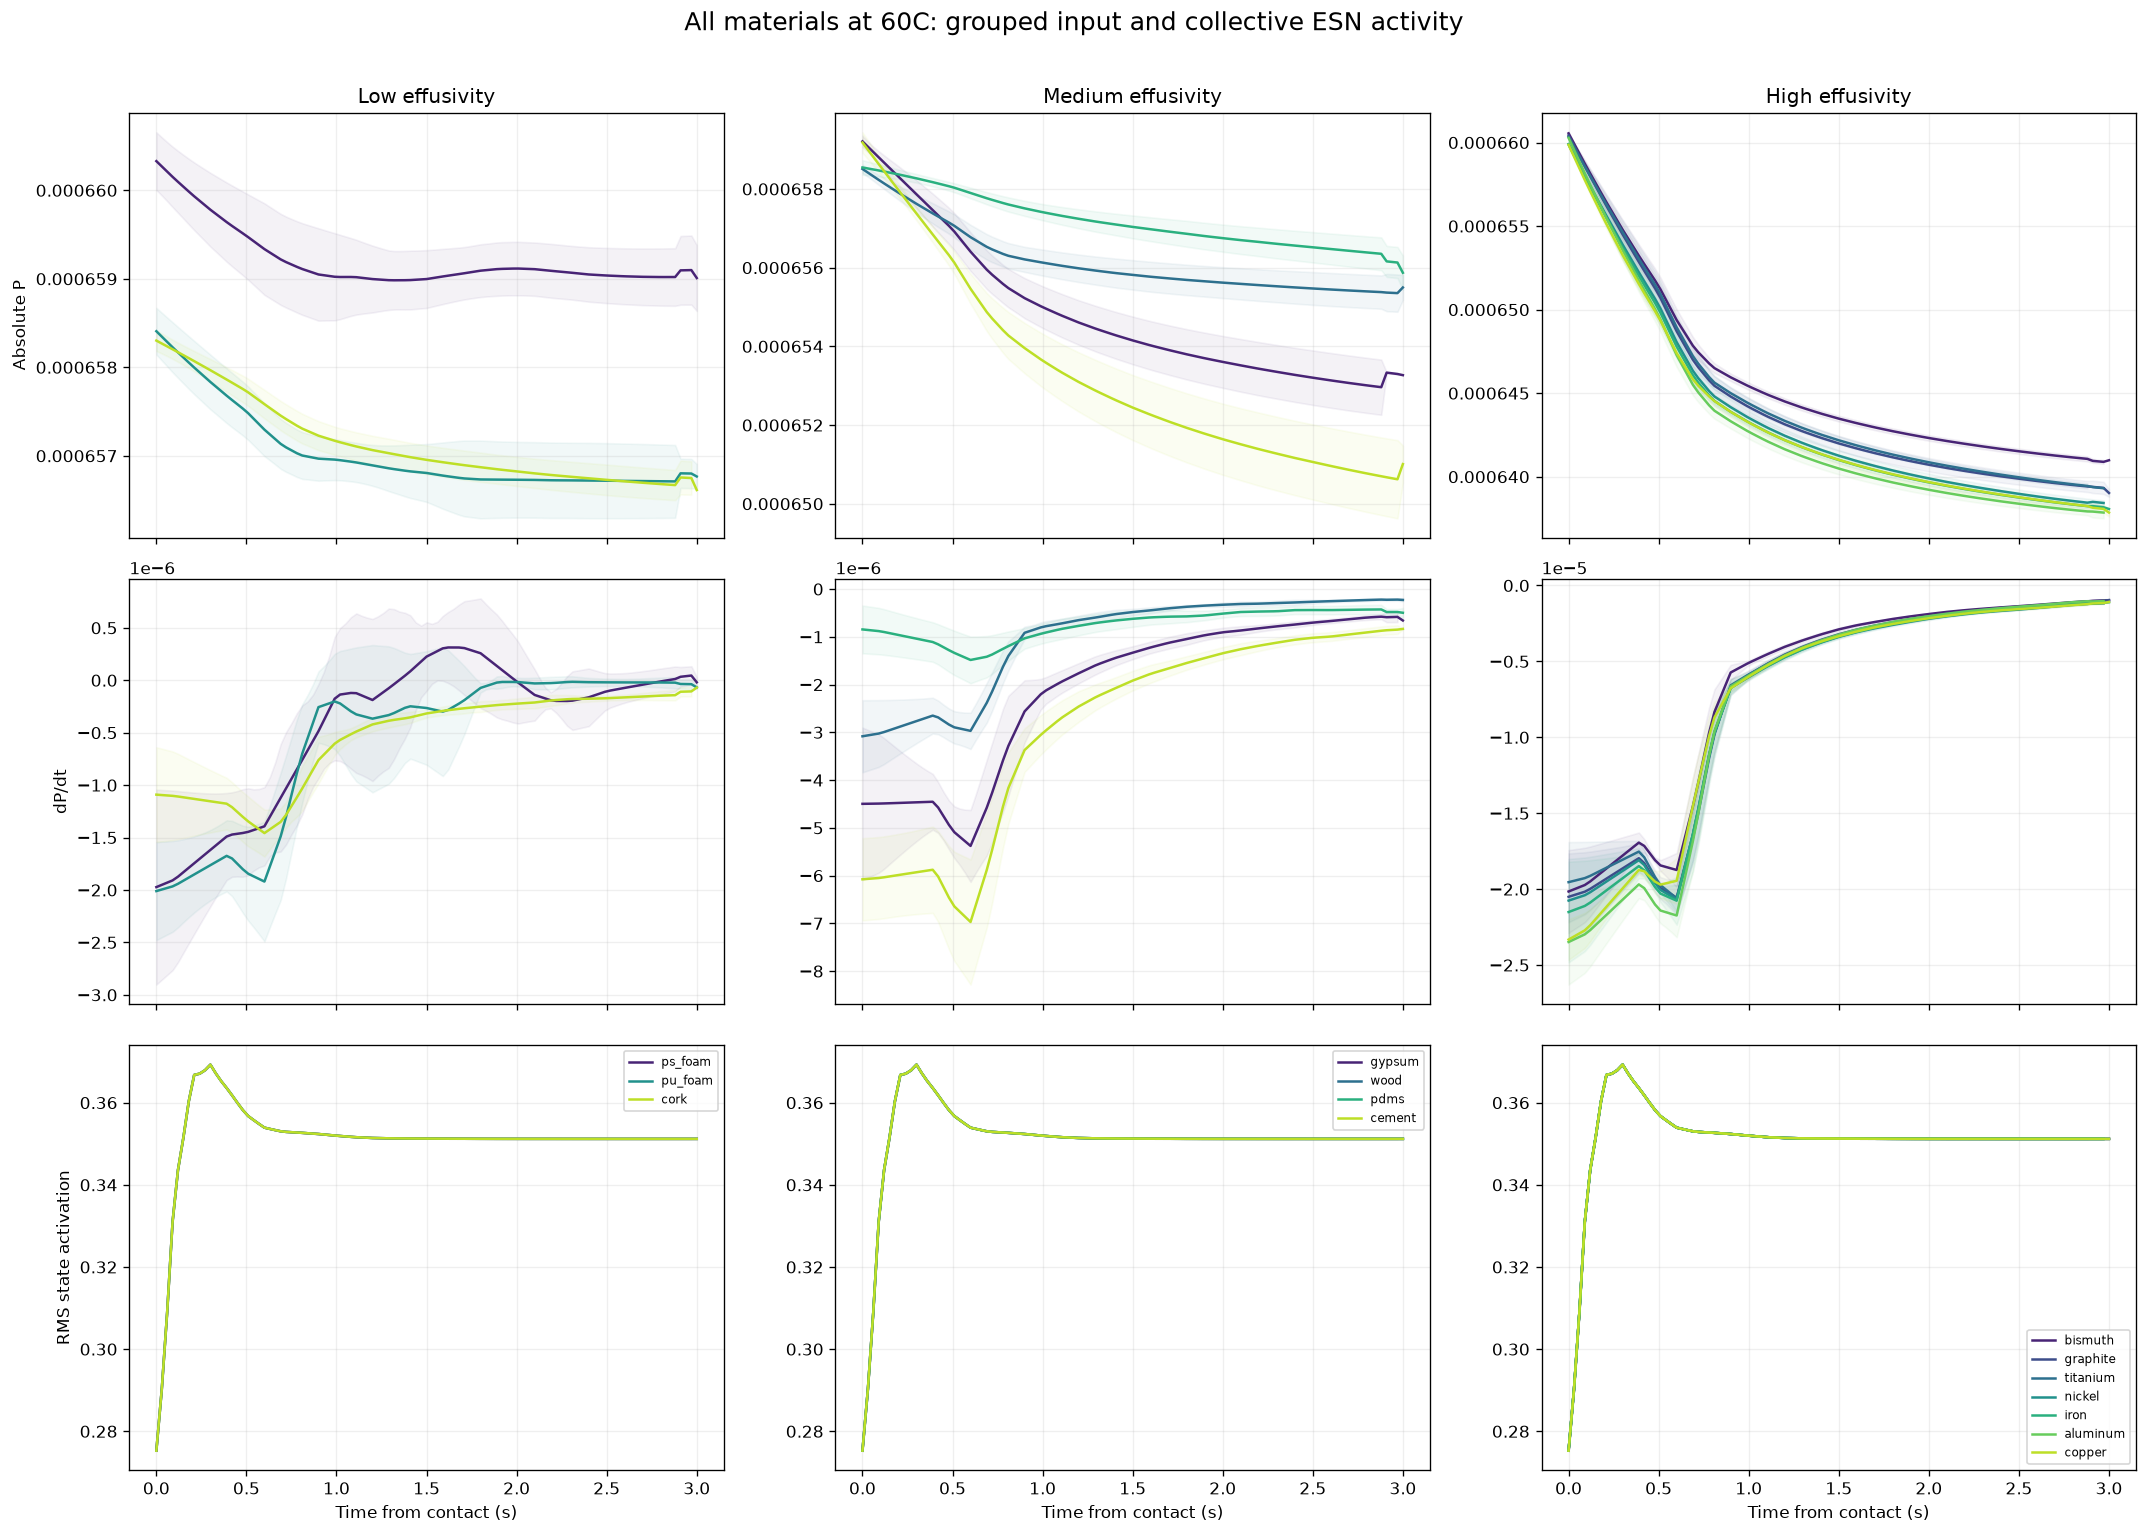

Saved: /Users/markkeanujamesexconde/Library/CloudStorage/OneDrive-Personal/Documents/Academe Files/4. Doctoral/Research 1 - Warmth Sensor/Warmth-Sensor-Object-Detection/results/input_esn_dynamics_4cv5/all_material_groups_60C.png


In [6]:
EFFUSIVITY_GROUPS = {
    "Low effusivity": ("ps_foam", "pu_foam", "cork"),
    "Medium effusivity": ("gypsum", "wood", "pdms", "cement"),
    "High effusivity": ("bismuth", "graphite", "titanium", "nickel", "iron", "aluminum", "copper"),
}
fig, axes = plt.subplots(3, 3, figsize=(18, 13), sharex="col")
for column, (group_name, members) in enumerate(EFFUSIVITY_GROUPS.items()):
    members = [x for x in members if x in available_samples]
    colors = plt.cm.viridis(np.linspace(0.10, 0.90, len(members)))
    for material, color in zip(members, colors):
        ids = METADATA.loc[
            (METADATA["Sample"] == material) & (METADATA["Temperature"] == SELECTED_TEMPERATURE),
            "trial_id",
        ].tolist()
        block = make_block(material, ids)
        for axis, column_index in ((axes[0, column], 0), (axes[1, column], 1)):
            mean, sd = block["input_mean"][:, column_index], block["input_sd"][:, column_index]
            axis.plot(TIME_GRID, mean, color=color, label=material)
            axis.fill_between(TIME_GRID, mean - sd, mean + sd, color=color, alpha=0.06)
        axes[2, column].plot(STATE_TIME_GRID, block["rms_mean"], color=color, label=material)
        axes[2, column].fill_between(
            STATE_TIME_GRID, block["rms_mean"] - block["rms_sd"],
            block["rms_mean"] + block["rms_sd"], color=color, alpha=0.06,
        )
    axes[0, column].set_title(group_name)
    axes[2, column].set_xlabel("Time from contact (s)")
    axes[2, column].legend(fontsize=7)
axes[0, 0].set_ylabel("Absolute P")
axes[1, 0].set_ylabel("dP/dt")
axes[2, 0].set_ylabel("RMS state activation")
fig.suptitle(f"All materials at {SELECTED_TEMPERATURE}: grouped input and collective ESN activity", fontsize=15)
fig.tight_layout(rect=(0, 0, 1, 0.97))
GROUP_FIGURE = save_figure(fig, f"all_material_groups_{SELECTED_TEMPERATURE}.png")

# 7. One material across four temperatures — aligned trial blocks

/var/folders/fx/p7h99klx61g3f9j63ld4_xcm0000gn/T/ipykernel_24228/4032576448.py:7: RuntimeWarning: Mean of empty slice
  rms_trials = [np.sqrt(np.nanmean(x["states"] ** 2, axis=1)) for x in payloads]


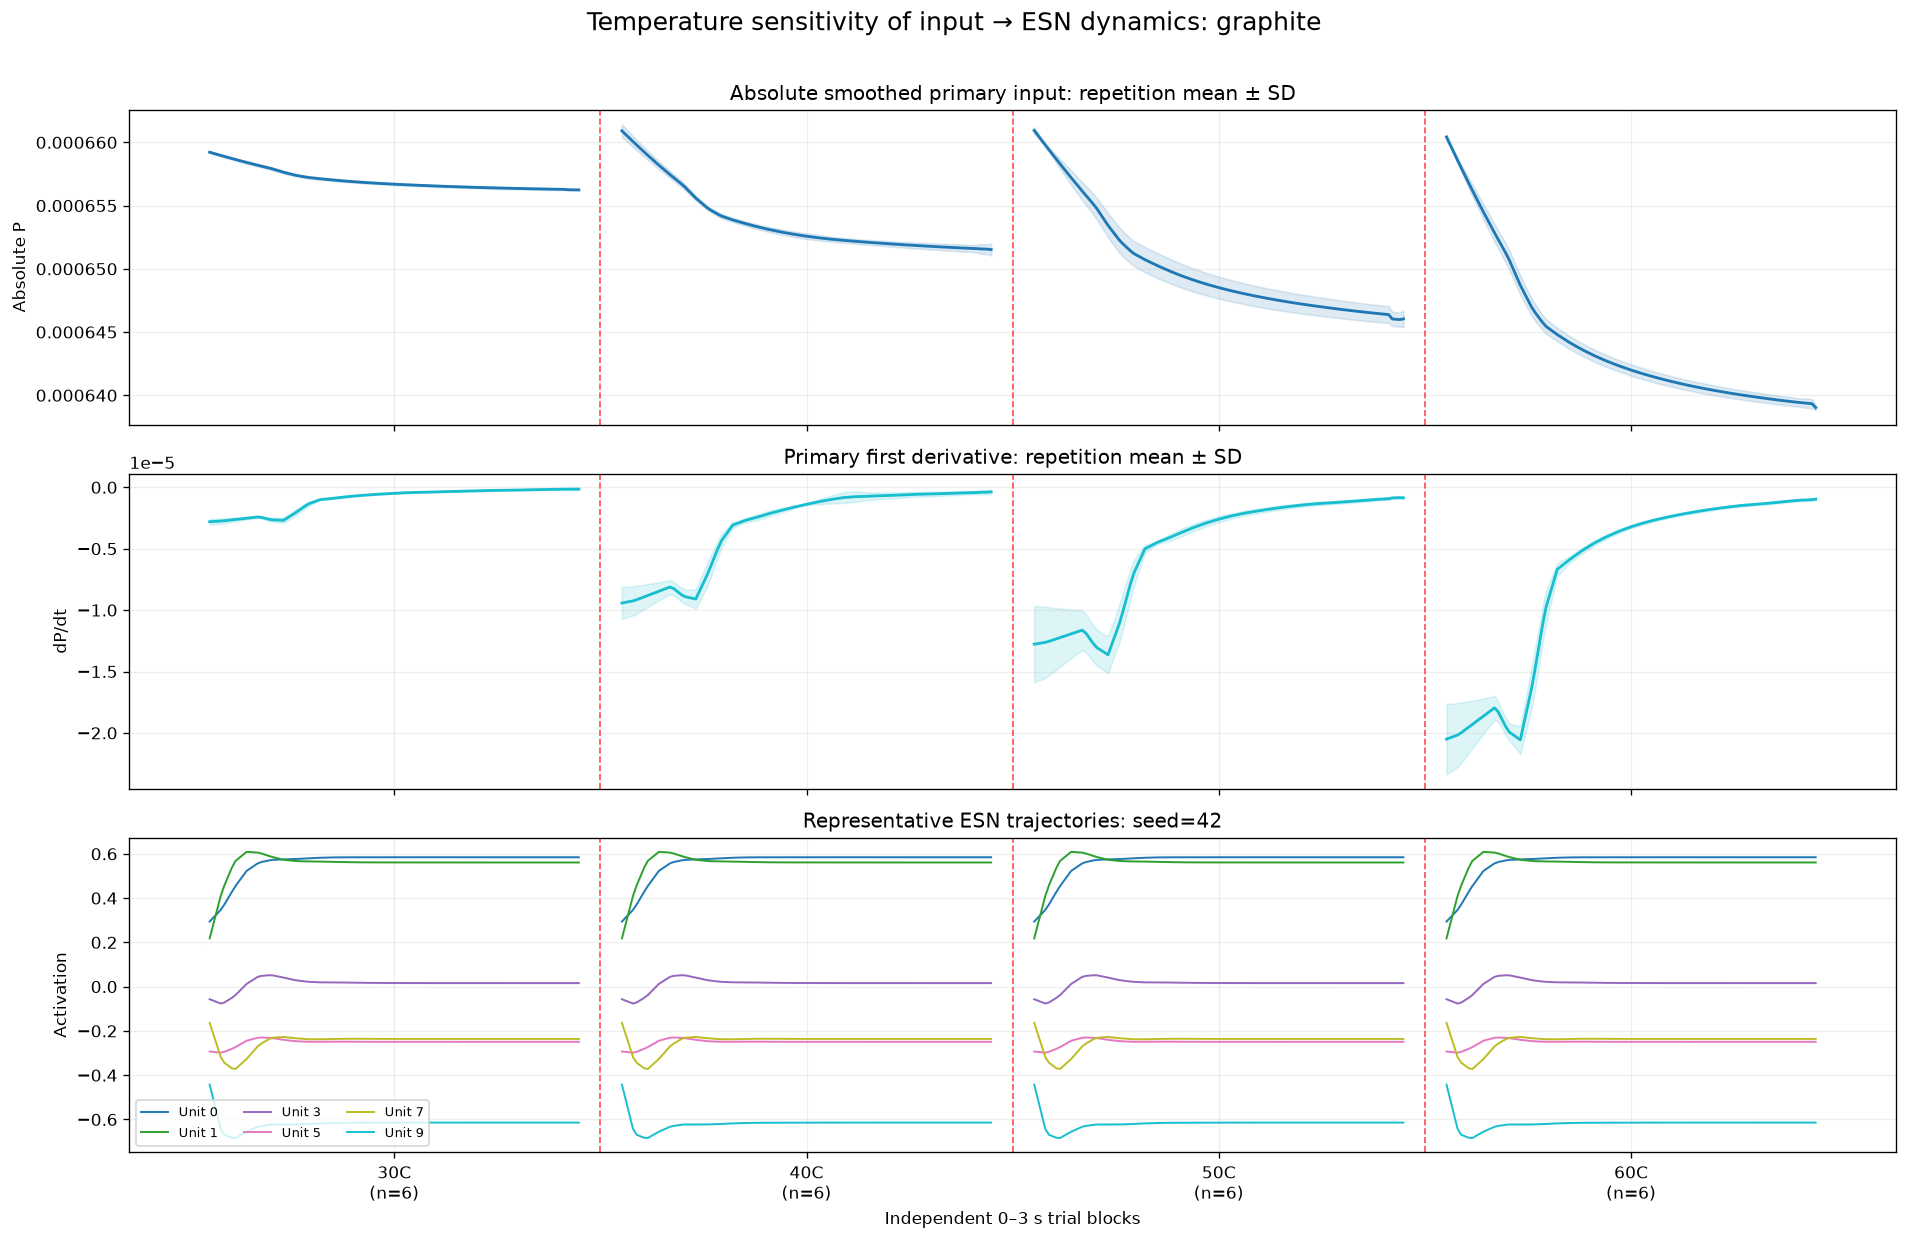

Saved: /Users/markkeanujamesexconde/Library/CloudStorage/OneDrive-Personal/Documents/Academe Files/4. Doctoral/Research 1 - Warmth Sensor/Warmth-Sensor-Object-Detection/results/input_esn_dynamics_4cv5/temperature_blocks_graphite.png


In [7]:
temperature_blocks = []
for temperature in TEMPERATURE_FOLDERS:
    ids = METADATA.loc[
        (METADATA["Sample"] == SELECTED_MATERIAL) & (METADATA["Temperature"] == temperature),
        "trial_id",
    ].tolist()
    temperature_blocks.append(make_block(temperature, ids))
TEMPERATURE_BLOCK_FIGURE = plot_input_state_correspondence(
    temperature_blocks,
    f"Temperature sensitivity of input → ESN dynamics: {SELECTED_MATERIAL}",
    f"temperature_blocks_{SELECTED_MATERIAL}.png",
)

# 8. Same-material temperature superposition

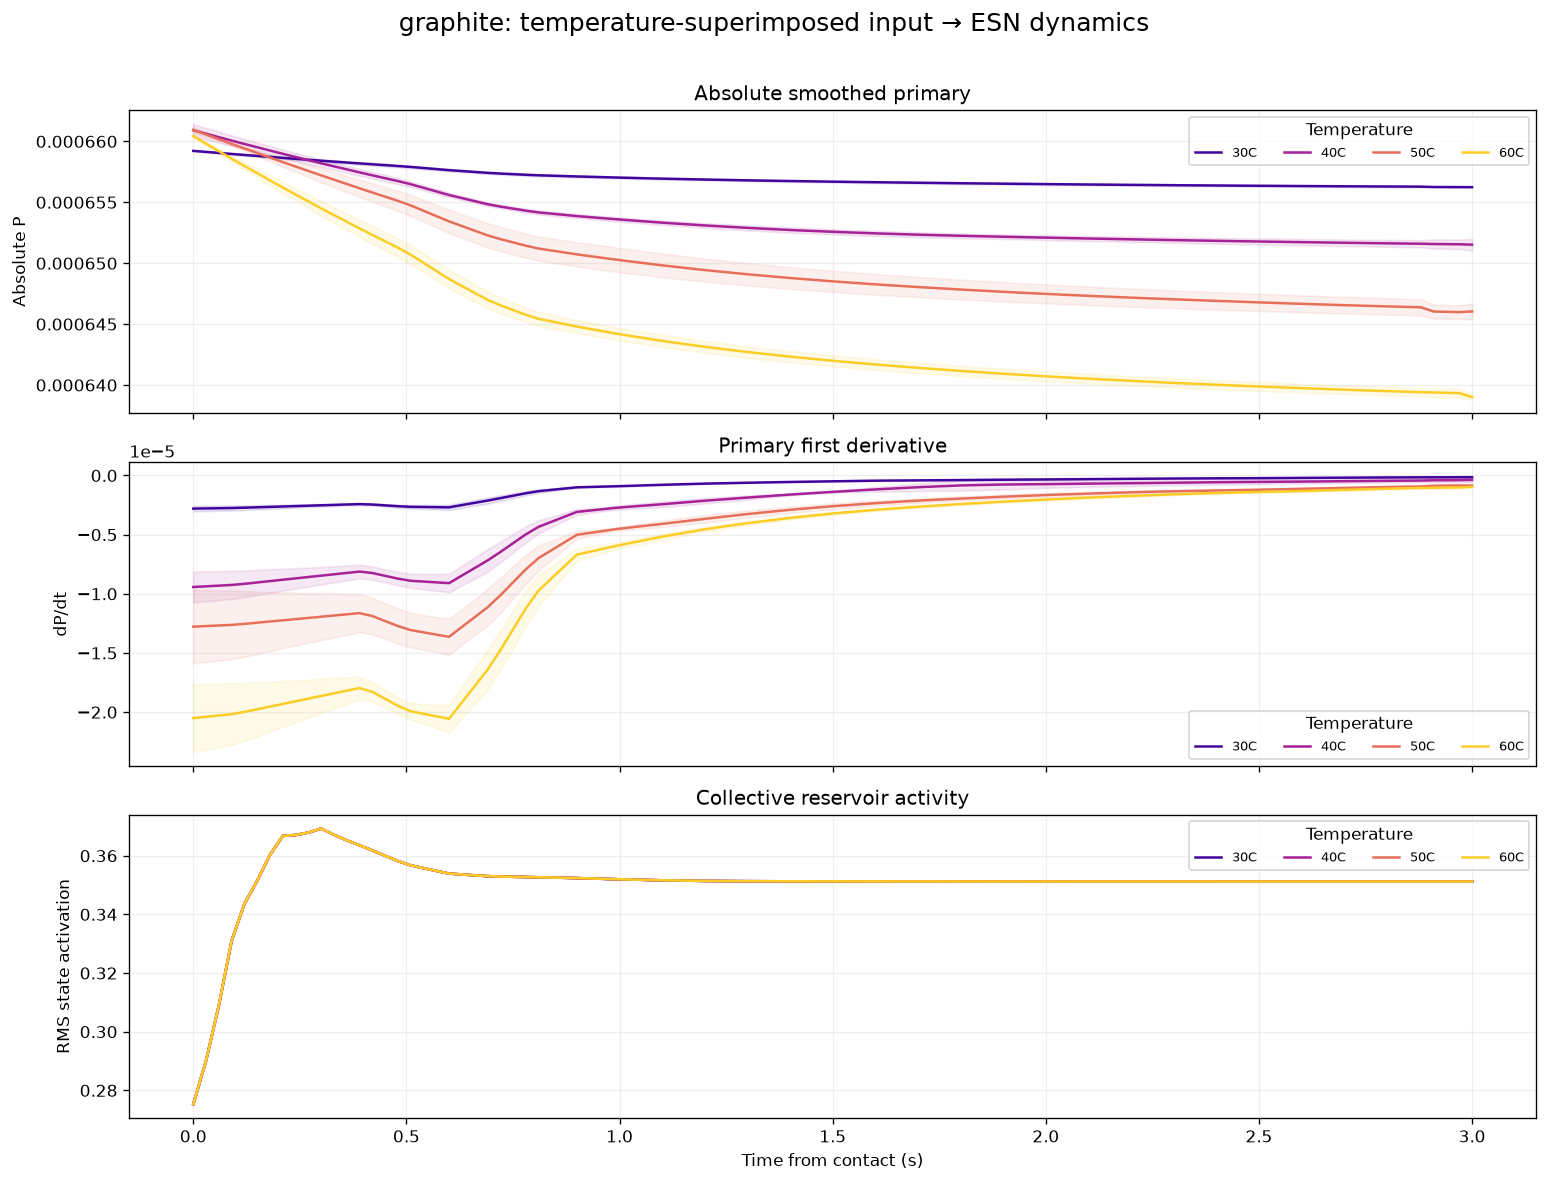

Saved: /Users/markkeanujamesexconde/Library/CloudStorage/OneDrive-Personal/Documents/Academe Files/4. Doctoral/Research 1 - Warmth Sensor/Warmth-Sensor-Object-Detection/results/input_esn_dynamics_4cv5/temperature_superposition_graphite.png


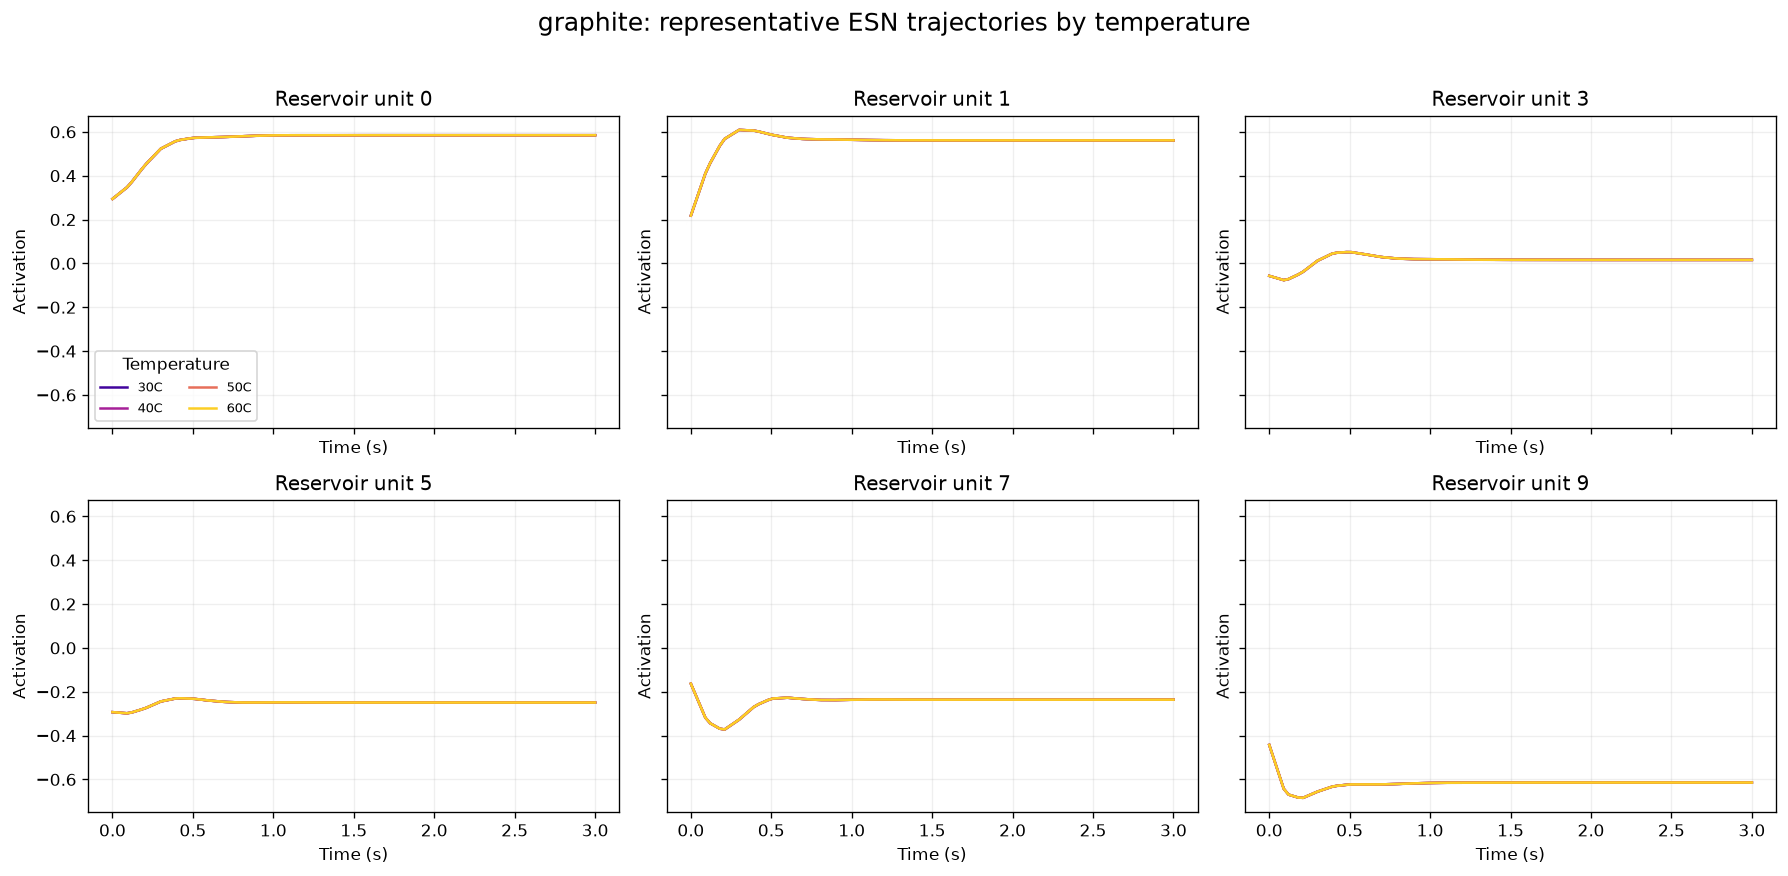

Saved: /Users/markkeanujamesexconde/Library/CloudStorage/OneDrive-Personal/Documents/Academe Files/4. Doctoral/Research 1 - Warmth Sensor/Warmth-Sensor-Object-Detection/results/input_esn_dynamics_4cv5/temperature_superposition_units_graphite.png


In [8]:
TEMPERATURE_COLORS = dict(zip(TEMPERATURE_FOLDERS, plt.cm.plasma(np.linspace(0.10, 0.90, 4))))
superimposed = {temperature: block for temperature, block in zip(TEMPERATURE_FOLDERS, temperature_blocks)}
fig, axes = plt.subplots(3, 1, figsize=(13, 10), sharex=True)
for temperature in TEMPERATURE_FOLDERS:
    block, color = superimposed[temperature], TEMPERATURE_COLORS[temperature]
    for axis, column_index in ((axes[0], 0), (axes[1], 1)):
        mean, sd = block["input_mean"][:, column_index], block["input_sd"][:, column_index]
        axis.plot(TIME_GRID, mean, color=color, label=temperature)
        axis.fill_between(TIME_GRID, mean - sd, mean + sd, color=color, alpha=0.10)
    axes[2].plot(STATE_TIME_GRID, block["rms_mean"], color=color, label=temperature)
    axes[2].fill_between(
        STATE_TIME_GRID, block["rms_mean"] - block["rms_sd"],
        block["rms_mean"] + block["rms_sd"], color=color, alpha=0.10,
    )
axes[0].set(ylabel="Absolute P", title="Absolute smoothed primary")
axes[1].set(ylabel="dP/dt", title="Primary first derivative")
axes[2].set(ylabel="RMS state activation", xlabel="Time from contact (s)",
            title="Collective reservoir activity")
for axis in axes: axis.legend(title="Temperature", ncol=4, fontsize=8)
fig.suptitle(f"{SELECTED_MATERIAL}: temperature-superimposed input → ESN dynamics", fontsize=15)
fig.tight_layout(rect=(0, 0, 1, 0.97))
SUPERIMPOSED_FIGURE = save_figure(fig, f"temperature_superposition_{SELECTED_MATERIAL}.png")

# Companion view: one panel per unit, temperatures overlaid consistently.
n_units = len(REPRESENTATIVE_UNITS); n_columns = min(3, n_units)
n_rows = int(np.ceil(n_units / n_columns))
fig, unit_axes = plt.subplots(n_rows, n_columns, figsize=(15, 3.7*n_rows), sharex=True, sharey=True)
unit_axes = np.atleast_1d(unit_axes).ravel()
for axis, unit in zip(unit_axes, REPRESENTATIVE_UNITS):
    for temperature in TEMPERATURE_FOLDERS:
        block, color = superimposed[temperature], TEMPERATURE_COLORS[temperature]
        mean, sd = block["state_mean"][:, unit], block["state_sd"][:, unit]
        axis.plot(STATE_TIME_GRID, mean, color=color, label=temperature)
        axis.fill_between(STATE_TIME_GRID, mean - sd, mean + sd, color=color, alpha=0.08)
    axis.set(title=f"Reservoir unit {unit}", xlabel="Time (s)", ylabel="Activation")
for axis in unit_axes[n_units:]: axis.set_visible(False)
unit_axes[0].legend(title="Temperature", ncol=2, fontsize=8)
fig.suptitle(f"{SELECTED_MATERIAL}: representative ESN trajectories by temperature", fontsize=15)
fig.tight_layout(rect=(0, 0, 1, 0.96))
UNIT_TEMPERATURE_FIGURE = save_figure(fig, f"temperature_superposition_units_{SELECTED_MATERIAL}.png")

# 9. Case-study materials with temperatures superimposed

/Users/markkeanujamesexconde/.virtualenvs/warmth-sensor-object-detection/lib/python3.13/site-packages/numpy/lib/_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/var/folders/fx/p7h99klx61g3f9j63ld4_xcm0000gn/T/ipykernel_24228/4032576448.py:7: RuntimeWarning: Mean of empty slice
  rms_trials = [np.sqrt(np.nanmean(x["states"] ** 2, axis=1)) for x in payloads]
/var/folders/fx/p7h99klx61g3f9j63ld4_xcm0000gn/T/ipykernel_24228/1989336205.py:66: RuntimeWarning: Mean of empty slice
  return np.nanmean(array, axis=0), (


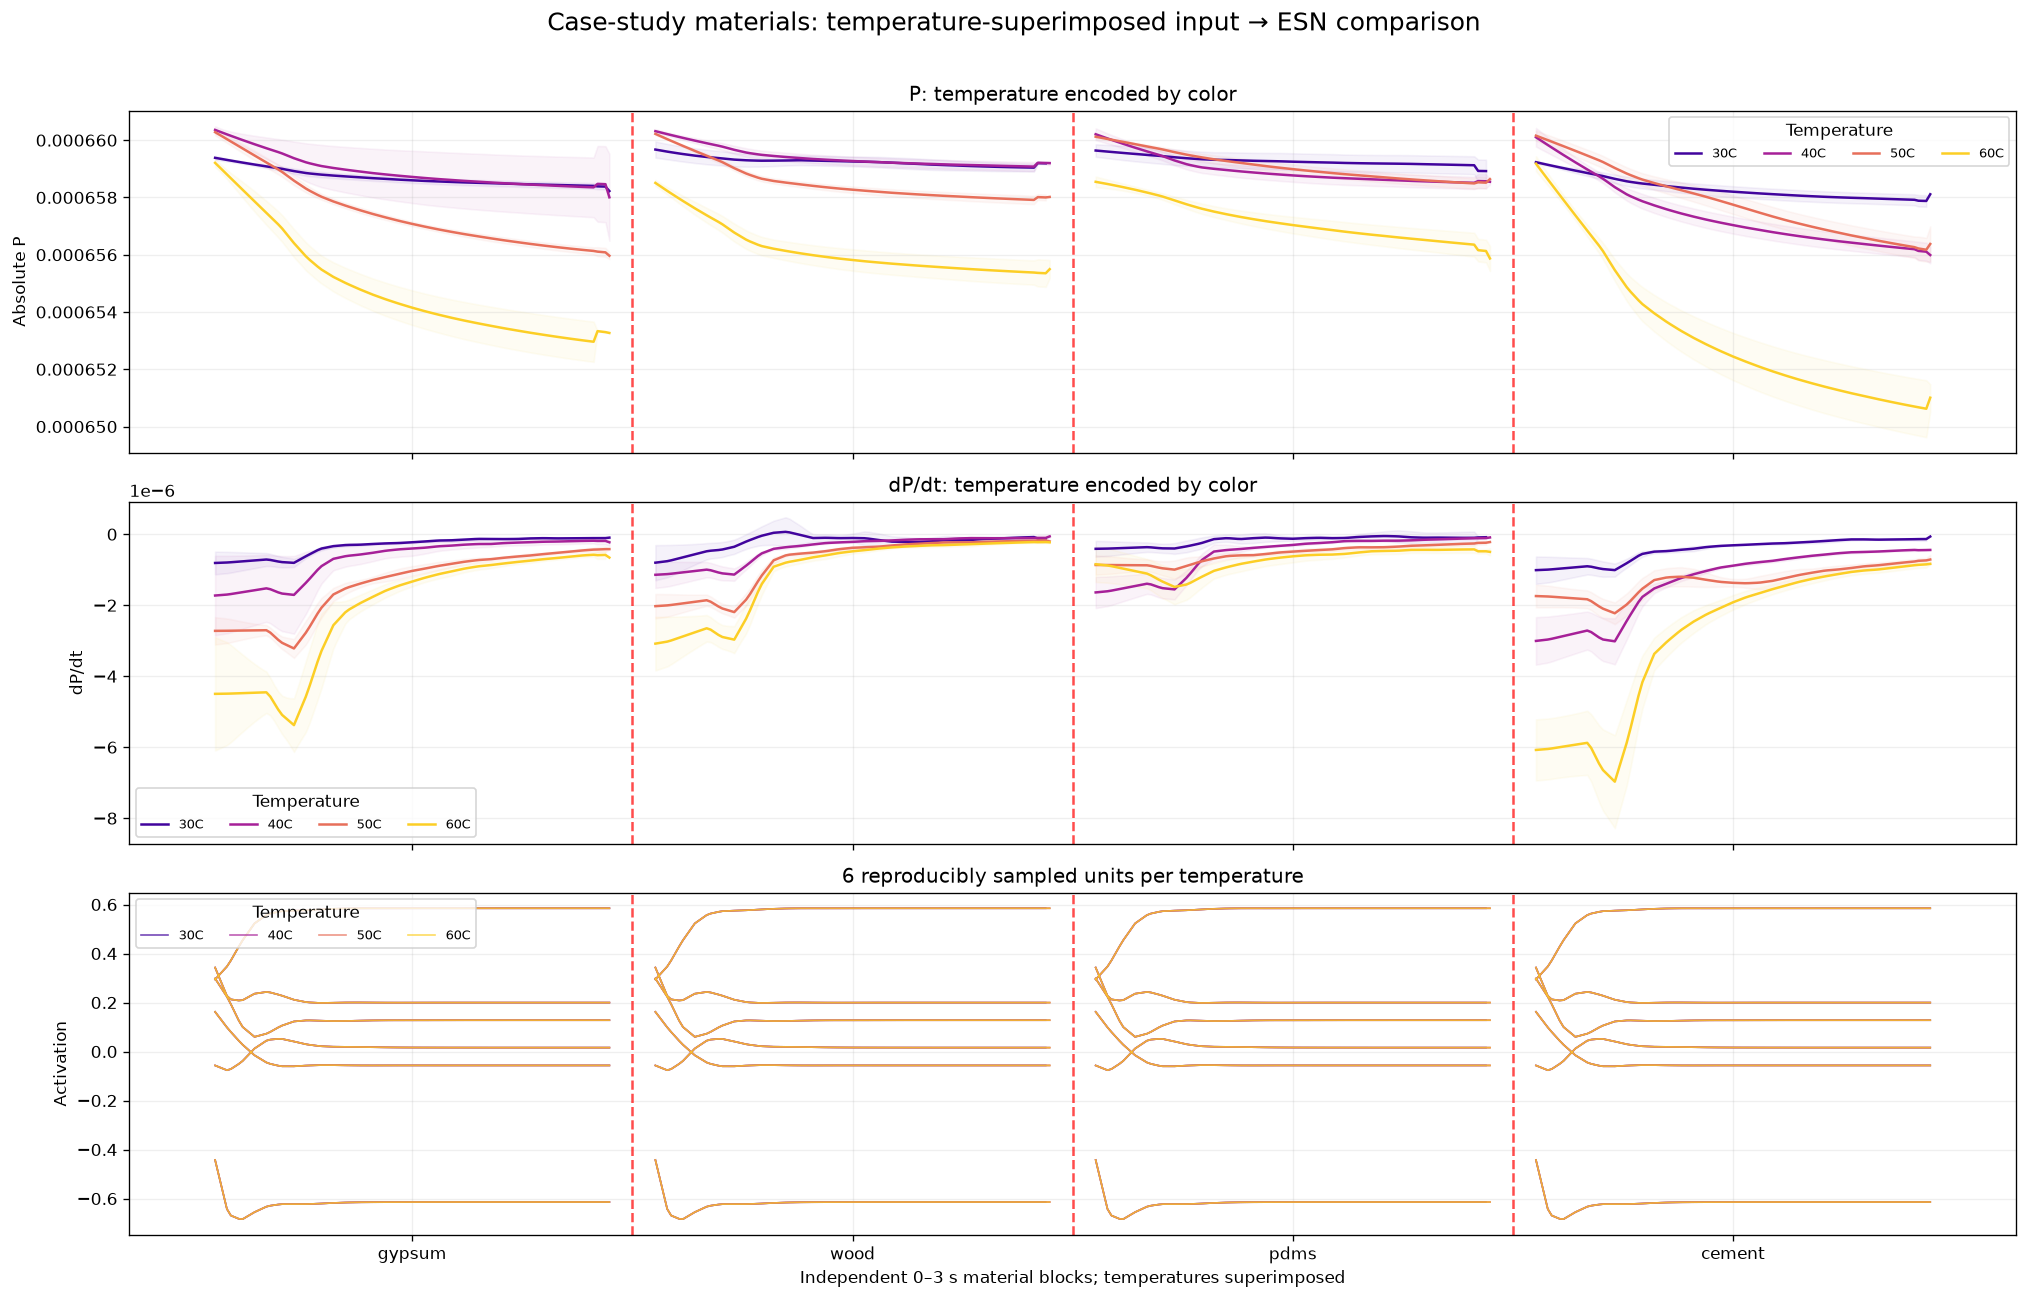

Saved: /Users/markkeanujamesexconde/Library/CloudStorage/OneDrive-Personal/Documents/Academe Files/4. Doctoral/Research 1 - Warmth Sensor/Warmth-Sensor-Object-Detection/results/input_esn_dynamics_4cv5/case_study_temperature_superposition.png


In [9]:
unit_count = min(GROUP_RANDOM_UNIT_COUNT, int(ESN_PARAMS["res_size"]))
GROUP_RANDOM_UNITS = np.sort(np.random.default_rng(DISPLAY_SEED).choice(
    int(ESN_PARAMS["res_size"]), size=unit_count, replace=False,
))
block_width = ANALYSIS_WINDOW[1] - ANALYSIS_WINDOW[0]; gap = 0.35
fig, axes = plt.subplots(3, 1, figsize=(17, 11), sharex=True)
centers, boundaries = [], []
for material_index, material in enumerate(CASE_STUDY_MATERIALS):
    offset = material_index * (block_width + gap); x = offset + TIME_GRID
    centers.append(offset + block_width/2); boundaries.append(offset + block_width + gap/2)
    for temperature in TEMPERATURE_FOLDERS:
        ids = METADATA.loc[
            (METADATA["Sample"] == material) & (METADATA["Temperature"] == temperature), "trial_id"
        ].tolist()
        block, color = make_block(temperature, ids), TEMPERATURE_COLORS[temperature]
        for axis, column_index in ((axes[0], 0), (axes[1], 1)):
            mean, sd = block["input_mean"][:, column_index], block["input_sd"][:, column_index]
            axis.plot(x, mean, color=color, label=temperature if material_index == 0 else None)
            axis.fill_between(x, mean - sd, mean + sd, color=color, alpha=0.05)
        for unit in GROUP_RANDOM_UNITS:
            axes[2].plot(offset + STATE_TIME_GRID, block["state_mean"][:, unit], color=color,
                         linewidth=1.0, alpha=0.72,
                         label=temperature if material_index == 0 and unit == GROUP_RANDOM_UNITS[0] else None)
for boundary in boundaries[:-1]:
    for axis in axes: axis.axvline(boundary, color="red", linestyle="--", alpha=0.7)
axes[0].set(ylabel="Absolute P", title="P: temperature encoded by color")
axes[1].set(ylabel="dP/dt", title="dP/dt: temperature encoded by color")
axes[2].set(ylabel="Activation", title=f"{unit_count} reproducibly sampled units per temperature")
for axis in axes: axis.legend(title="Temperature", ncol=4, fontsize=8)
axes[2].set_xticks(centers, CASE_STUDY_MATERIALS)
axes[2].set_xlabel("Independent 0–3 s material blocks; temperatures superimposed")
fig.suptitle("Case-study materials: temperature-superimposed input → ESN comparison", fontsize=15)
fig.tight_layout(rect=(0, 0, 1, 0.97))
CASE_TEMPERATURE_FIGURE = save_figure(fig, "case_study_temperature_superposition.png")

# 10. Six nominally identical repetitions

/var/folders/fx/p7h99klx61g3f9j63ld4_xcm0000gn/T/ipykernel_24228/1989336205.py:66: RuntimeWarning: Mean of empty slice
  return np.nanmean(array, axis=0), (
/var/folders/fx/p7h99klx61g3f9j63ld4_xcm0000gn/T/ipykernel_24228/4032576448.py:7: RuntimeWarning: Mean of empty slice
  rms_trials = [np.sqrt(np.nanmean(x["states"] ** 2, axis=1)) for x in payloads]


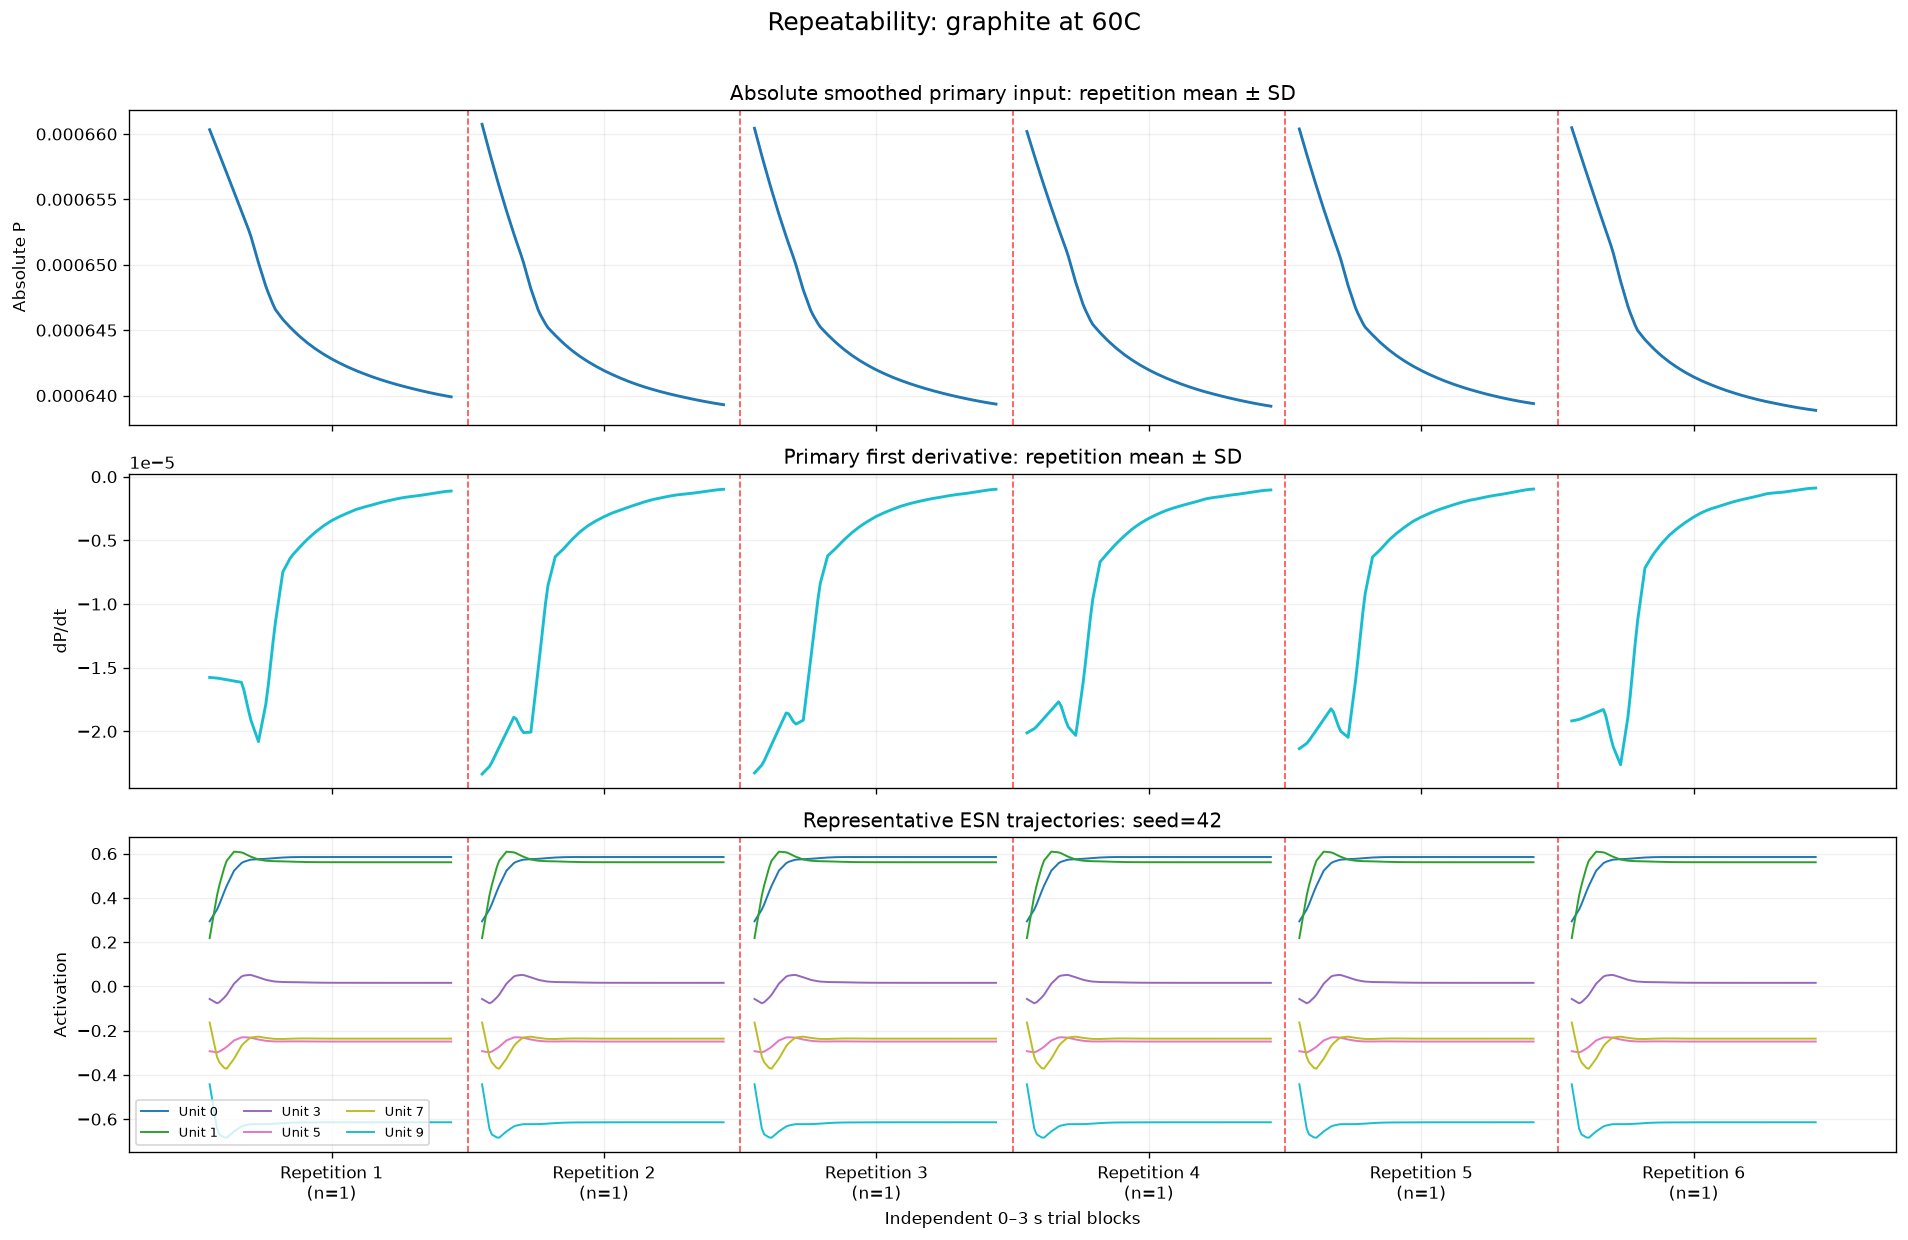

Saved: /Users/markkeanujamesexconde/Library/CloudStorage/OneDrive-Personal/Documents/Academe Files/4. Doctoral/Research 1 - Warmth Sensor/Warmth-Sensor-Object-Detection/results/input_esn_dynamics_4cv5/repetition_comparison_graphite_60C.png


In [10]:
rows = METADATA[
    (METADATA["Sample"] == REPETITION_MATERIAL)
    & (METADATA["Temperature"] == REPETITION_TEMPERATURE)
].sort_values("Trial")
repetition_blocks = [
    make_block(f"Repetition {int(row.Trial)}", [row.trial_id]) for row in rows.itertuples()
]
REPETITION_FIGURE = plot_input_state_correspondence(
    repetition_blocks,
    f"Repeatability: {REPETITION_MATERIAL} at {REPETITION_TEMPERATURE}",
    f"repetition_comparison_{REPETITION_MATERIAL}_{REPETITION_TEMPERATURE}.png",
)

# 11. All-unit state heatmaps across temperatures

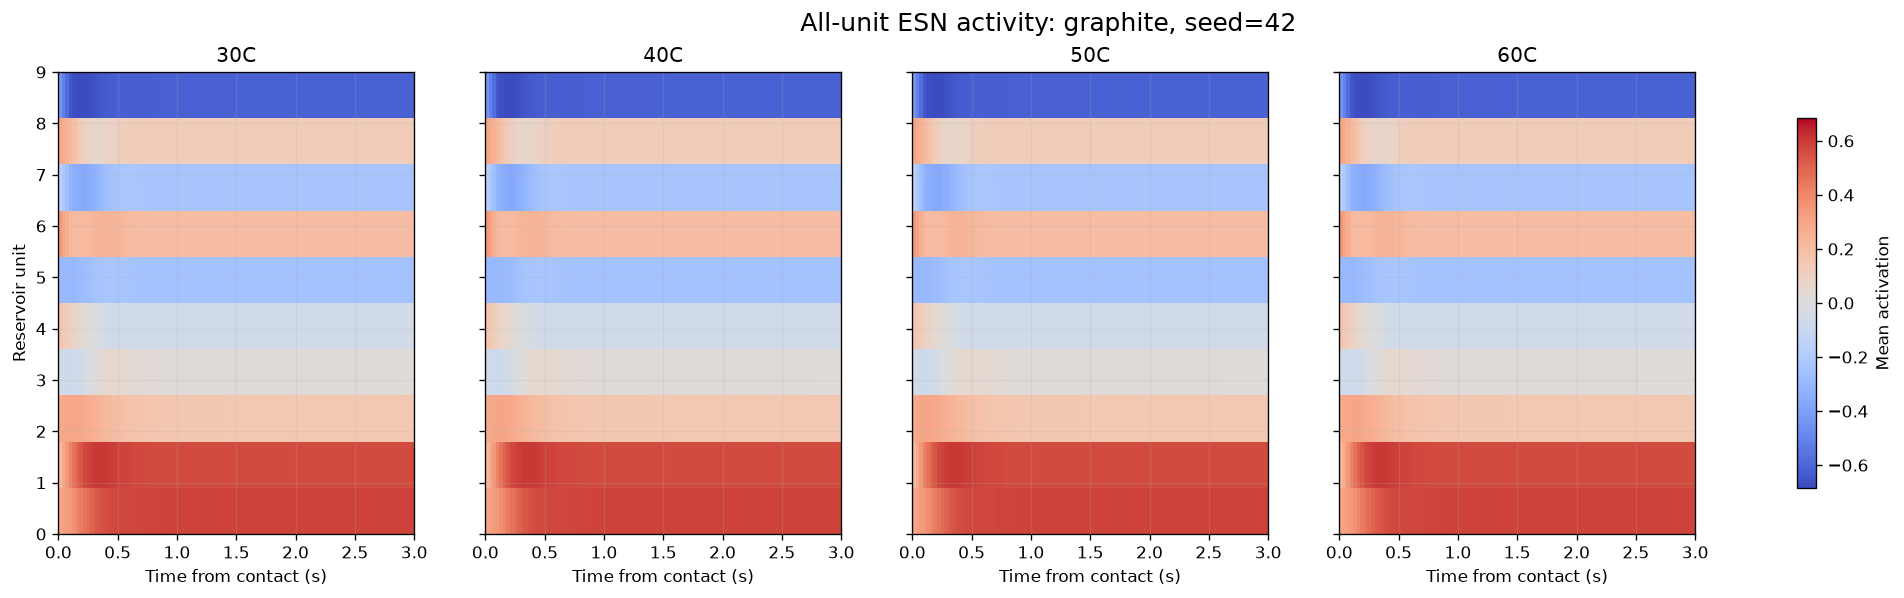

Saved: /Users/markkeanujamesexconde/Library/CloudStorage/OneDrive-Personal/Documents/Academe Files/4. Doctoral/Research 1 - Warmth Sensor/Warmth-Sensor-Object-Detection/results/input_esn_dynamics_4cv5/all_unit_heatmaps_graphite.png


In [11]:
heatmaps = []
for temperature in TEMPERATURE_FOLDERS:
    ids = METADATA.loc[
        (METADATA["Sample"] == SELECTED_MATERIAL) & (METADATA["Temperature"] == temperature), "trial_id"
    ].tolist()
    heatmaps.append(np.nanmean(np.stack([trial_diagnostics(x)["states"] for x in ids]), axis=0).T)
limit = max(np.nanmax(np.abs(x)) for x in heatmaps)
fig, axes = plt.subplots(1, 4, figsize=(22, 5), sharey=True)
for axis, temperature, matrix in zip(axes, TEMPERATURE_FOLDERS, heatmaps):
    image = axis.imshow(matrix, aspect="auto", origin="lower", cmap="coolwarm",
                        vmin=-limit, vmax=limit, extent=[*ANALYSIS_WINDOW, 0, matrix.shape[0]-1])
    axis.set(title=temperature, xlabel="Time from contact (s)")
axes[0].set_ylabel("Reservoir unit")
fig.colorbar(image, ax=axes, label="Mean activation", shrink=0.8)
fig.suptitle(f"All-unit ESN activity: {SELECTED_MATERIAL}, seed={DISPLAY_SEED}", fontsize=15)
HEATMAP_FIGURE = save_figure(fig, f"all_unit_heatmaps_{SELECTED_MATERIAL}.png")

# 12. Quantify input-to-dynamics relationships

These are descriptive dynamics measures, not prediction metrics. They test whether stronger or
more rapidly changing primary inputs correspond to stronger, more variable, or more saturated
reservoir responses.

,Sample,Temperature,P_peak_to_peak,dPdt_max_abs,state_mean_rms,state_temporal_variability,state_path_length,state_saturation_fraction
0,aluminum,30C,0.000003,0.000003,0.478349,0.051260,1.081712,0.0
1,aluminum,40C,0.000009,0.000009,0.478259,0.051513,1.081718,0.0
2,aluminum,50C,0.000017,0.000019,0.478350,0.051261,1.081728,0.0
3,aluminum,60C,0.000022,0.000024,0.478305,0.051387,1.081734,0.0
4,bismuth,30C,0.000003,0.000003,0.478304,0.051386,1.081711,0.0
5,bismuth,40C,0.000008,0.000009,0.478349,0.051260,1.081718,0.0
6,bismuth,50C,0.000015,0.000017,0.478440,0.051008,1.081726,0.0
7,bismuth,60C,0.000020,0.000021,0.478304,0.051387,1.081730,0.0
8,cement,30C,0.000001,0.000001,0.478394,0.051133,1.081709,0.0
9,cement,40C,0.000004,0.000003,0.478349,0.051260,1.081712,0.0


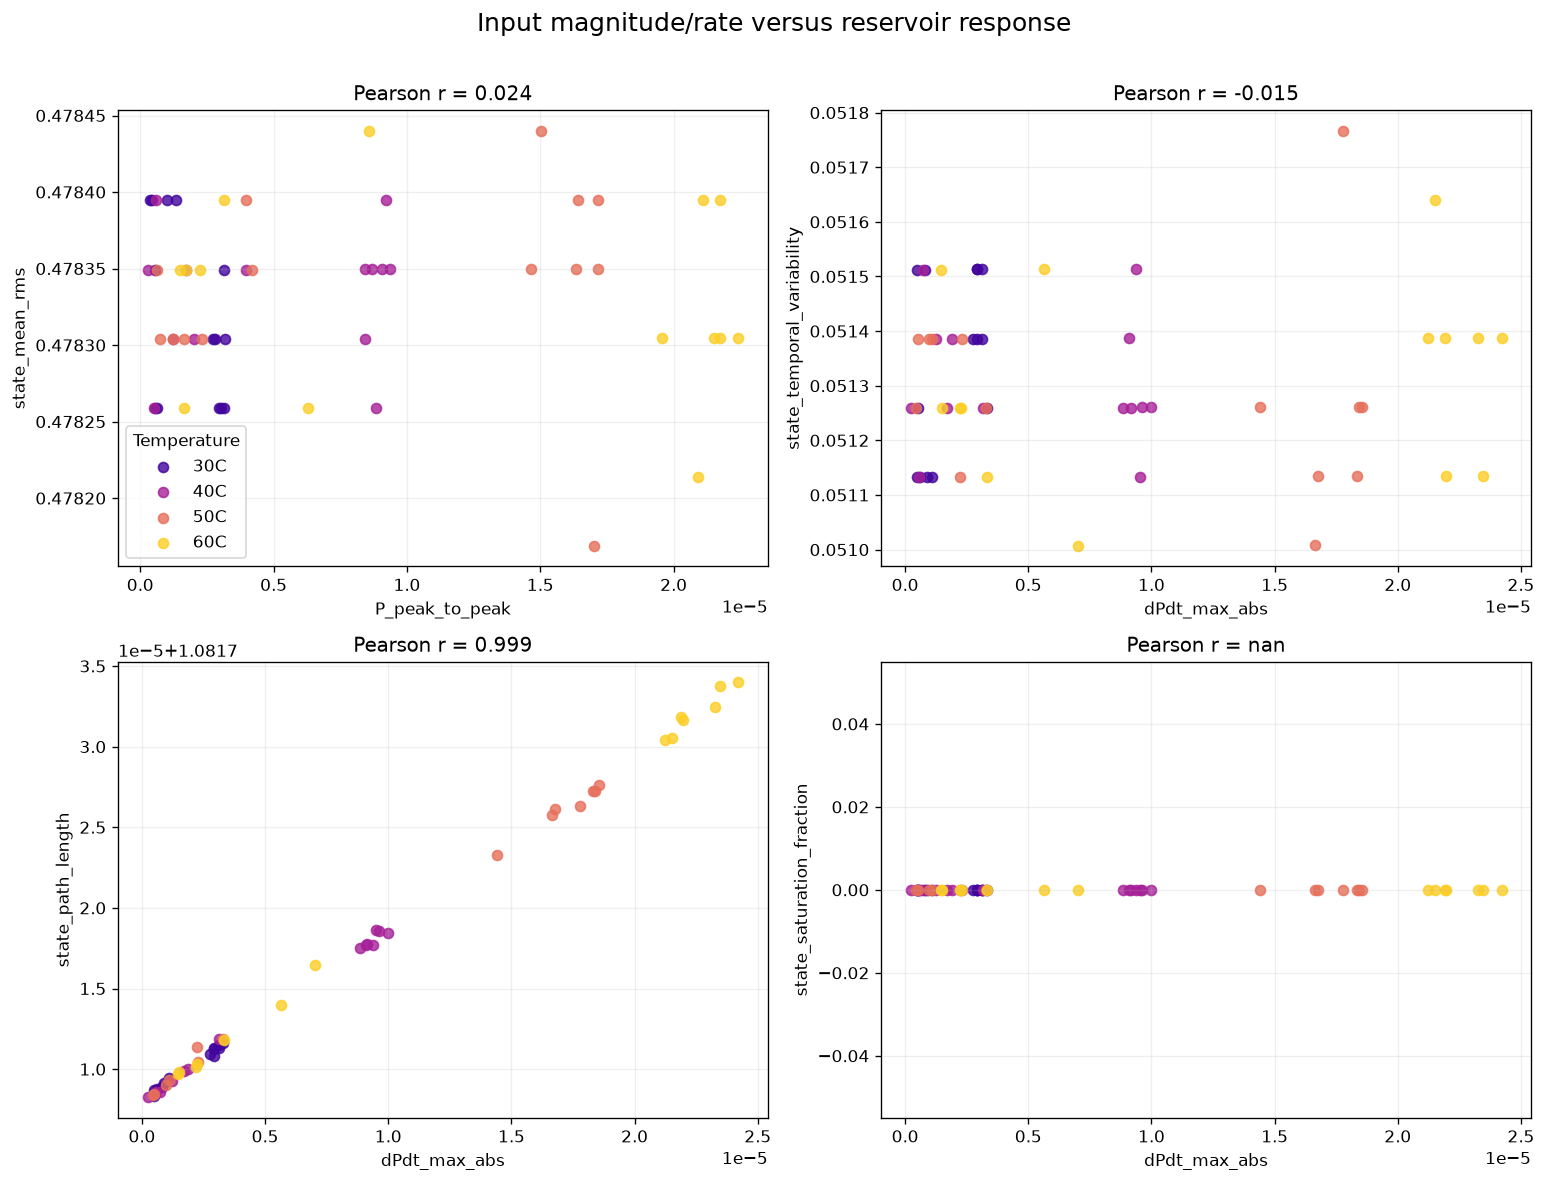

Saved: /Users/markkeanujamesexconde/Library/CloudStorage/OneDrive-Personal/Documents/Academe Files/4. Doctoral/Research 1 - Warmth Sensor/Warmth-Sensor-Object-Detection/results/input_esn_dynamics_4cv5/input_to_esn_relationships.png


In [12]:
metric_rows = []
for meta in METADATA.itertuples(index=False):
    trial = aligned_trials[meta.trial_id]
    time = trial["time_from_contact"].to_numpy(float)
    inputs = raw_esn_input(trial); primary, primary_rate = inputs[:, 0], inputs[:, 1]
    for seed in RESERVOIR_SEEDS:
        states = ManualReservoir(ESN_PARAMS, seed).run(inputs)
        state_time = time[int(ESN_PARAMS["washout"]):]
        state_rms_t = np.sqrt(np.mean(states**2, axis=1))
        metric_rows.append({
            "trial_id": meta.trial_id, "Sample": meta.Sample, "Temperature": meta.Temperature,
            "Trial": meta.Trial, "reservoir_seed": seed,
            "P_peak_to_peak": float(np.ptp(primary)),
            "P_net_change": float(primary[-1] - primary[0]),
            "dPdt_max_abs": float(np.max(np.abs(primary_rate))),
            "dPdt_abs_auc": float(np.trapezoid(np.abs(primary_rate), time)),
            "state_mean_rms": float(np.mean(state_rms_t)),
            "state_temporal_variability": float(np.mean(np.std(states, axis=0, ddof=0))),
            "state_mean_abs": float(np.mean(np.abs(states))),
            "state_path_length": float(np.sum(np.linalg.norm(np.diff(states, axis=0), axis=1))),
            "state_saturation_fraction": float(np.mean(np.abs(states) > 0.95)),
        })
DYNAMICS_TRIAL_METRICS = pd.DataFrame(metric_rows)
DYNAMICS_GROUP_SUMMARY = DYNAMICS_TRIAL_METRICS.groupby(
    ["Sample", "Temperature"], as_index=False
).agg(
    P_peak_to_peak=("P_peak_to_peak", "mean"),
    dPdt_max_abs=("dPdt_max_abs", "mean"),
    state_mean_rms=("state_mean_rms", "mean"),
    state_temporal_variability=("state_temporal_variability", "mean"),
    state_path_length=("state_path_length", "mean"),
    state_saturation_fraction=("state_saturation_fraction", "mean"),
)
display(DYNAMICS_GROUP_SUMMARY.head(12))

pairs = [
    ("P_peak_to_peak", "state_mean_rms"),
    ("dPdt_max_abs", "state_temporal_variability"),
    ("dPdt_max_abs", "state_path_length"),
    ("dPdt_max_abs", "state_saturation_fraction"),
]
fig, axes = plt.subplots(2, 2, figsize=(13, 10))
for axis, (x_name, y_name) in zip(axes.ravel(), pairs):
    for temperature, part in DYNAMICS_GROUP_SUMMARY.groupby("Temperature"):
        axis.scatter(part[x_name], part[y_name], color=TEMPERATURE_COLORS[temperature],
                     label=temperature, alpha=0.8)
    valid = DYNAMICS_GROUP_SUMMARY[[x_name, y_name]].dropna()
    correlation = valid.corr().iloc[0, 1]
    axis.set(xlabel=x_name, ylabel=y_name, title=f"Pearson r = {correlation:.3f}")
axes[0, 0].legend(title="Temperature")
fig.suptitle("Input magnitude/rate versus reservoir response", fontsize=15)
fig.tight_layout(rect=(0, 0, 1, 0.97))
RELATIONSHIP_FIGURE = save_figure(fig, "input_to_esn_relationships.png")

# 13. Material × temperature dynamics maps and exports

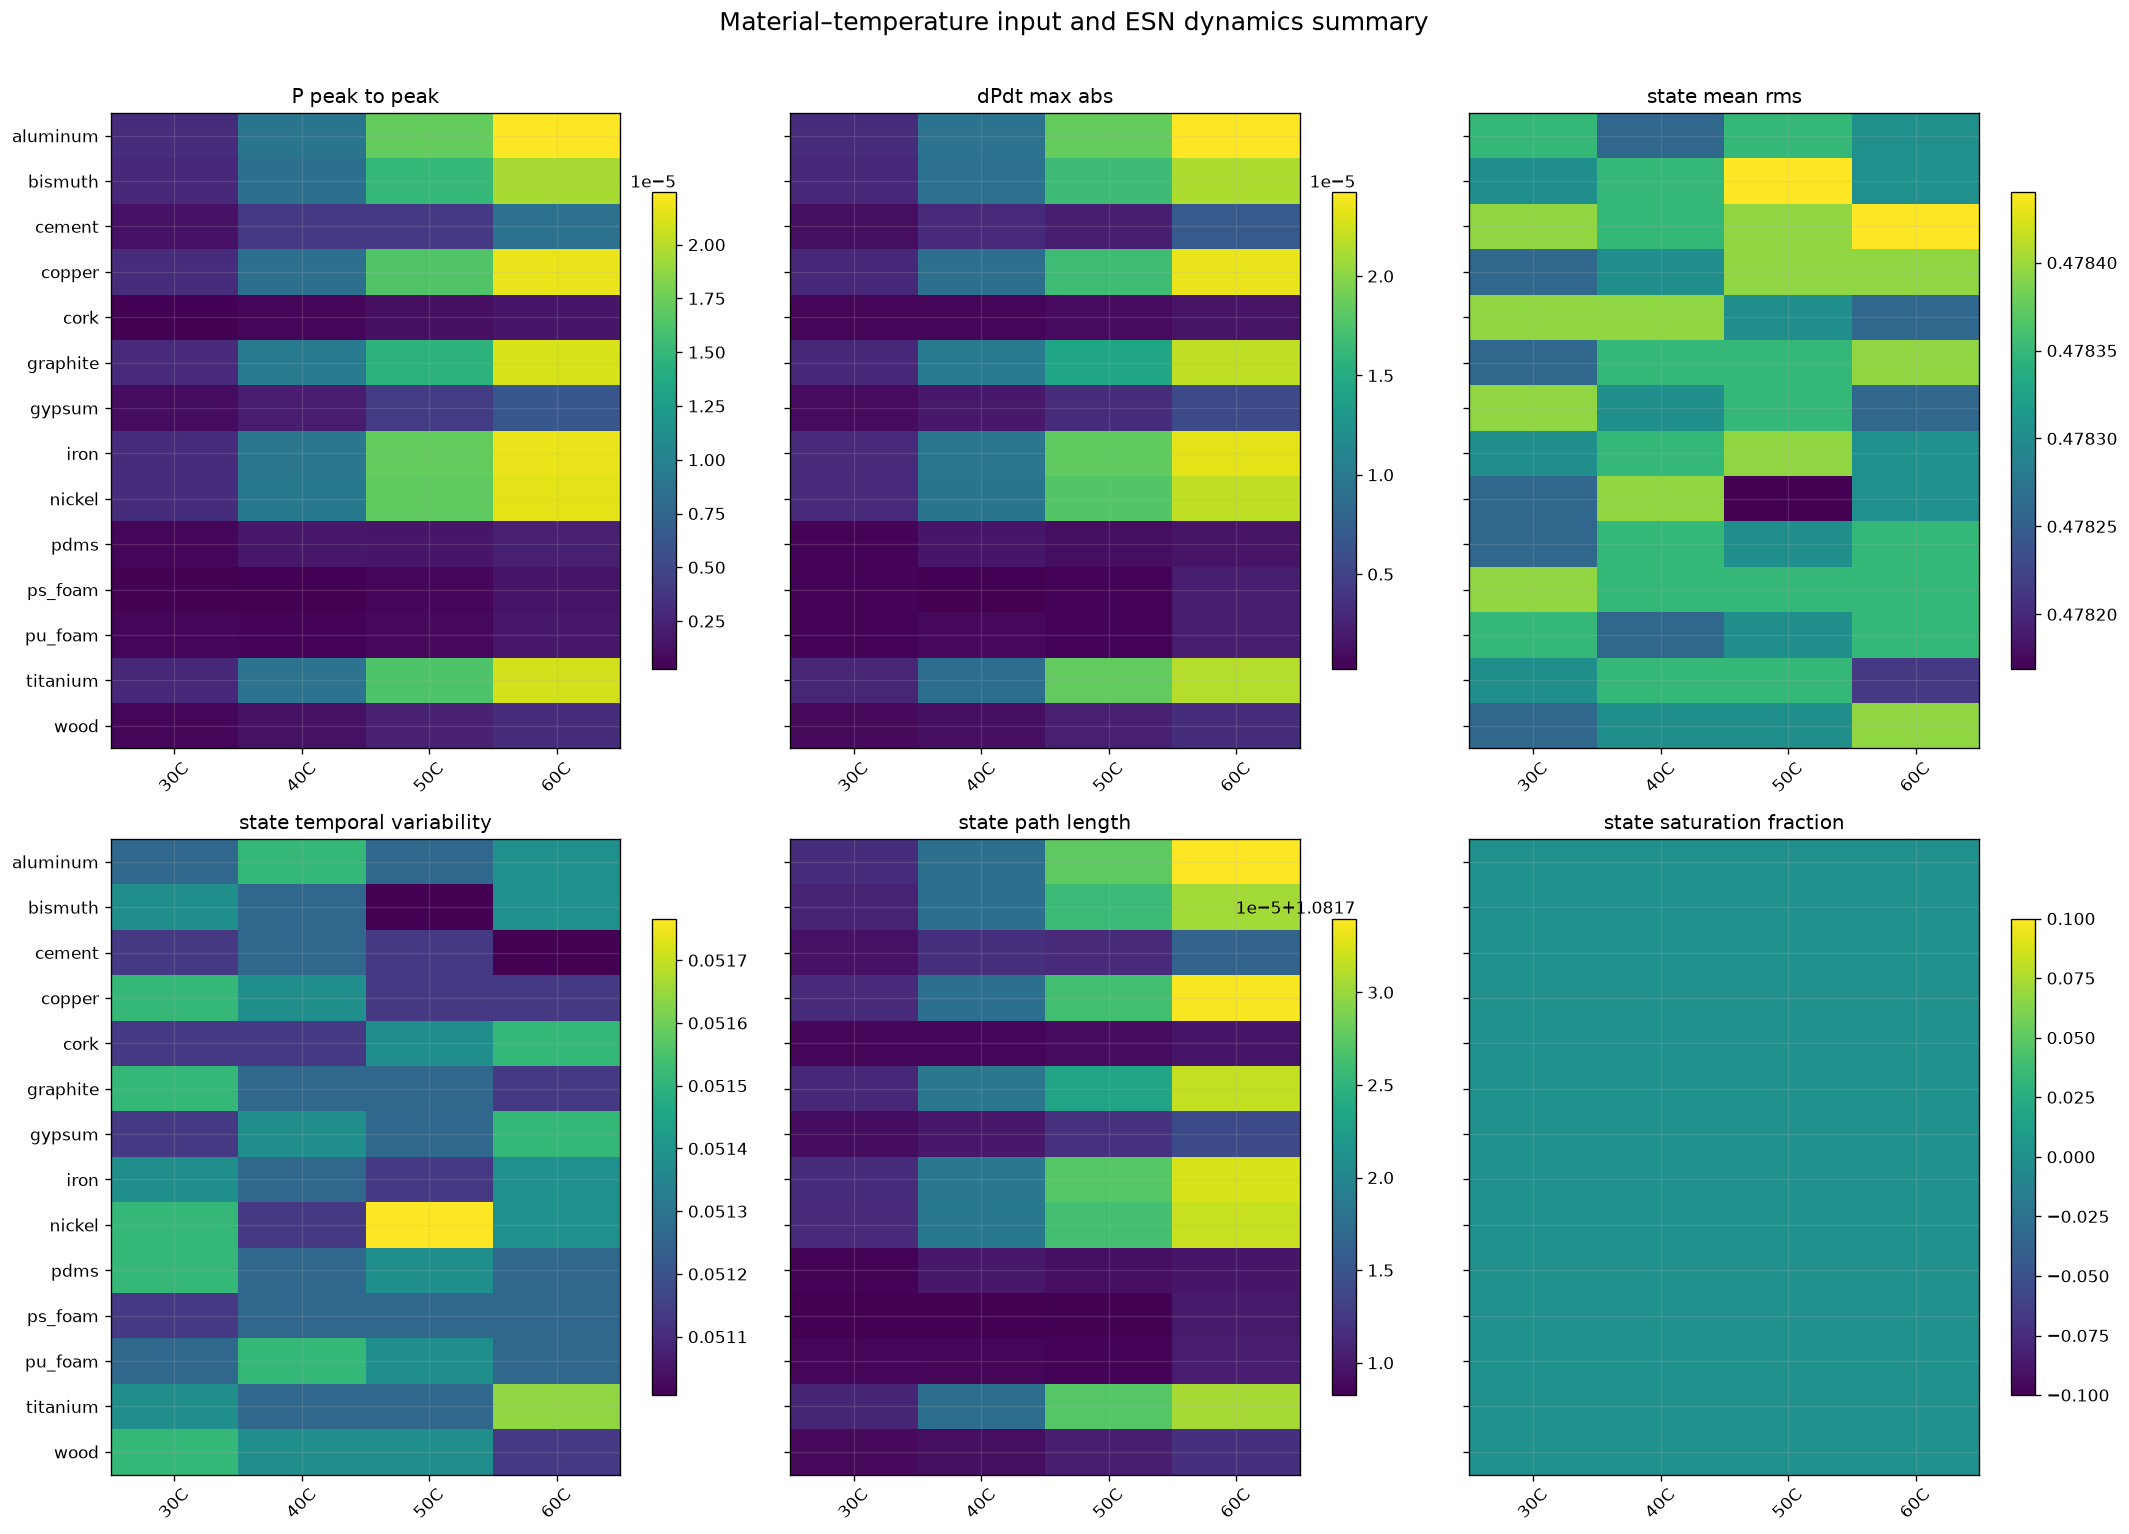

Saved: /Users/markkeanujamesexconde/Library/CloudStorage/OneDrive-Personal/Documents/Academe Files/4. Doctoral/Research 1 - Warmth Sensor/Warmth-Sensor-Object-Detection/results/input_esn_dynamics_4cv5/material_temperature_dynamics_maps.png
Saved: /Users/markkeanujamesexconde/Library/CloudStorage/OneDrive-Personal/Documents/Academe Files/4. Doctoral/Research 1 - Warmth Sensor/Warmth-Sensor-Object-Detection/results/multi_temp_esn/30C-40C-50C-60C_eff_4cv5_primary_dprimary_input_to_esn_dynamics_trial_seed_metrics.csv
Saved: /Users/markkeanujamesexconde/Library/CloudStorage/OneDrive-Personal/Documents/Academe Files/4. Doctoral/Research 1 - Warmth Sensor/Warmth-Sensor-Object-Detection/results/multi_temp_esn/30C-40C-50C-60C_eff_4cv5_primary_dprimary_input_to_esn_dynamics_material_temperature_summary.csv
Diagnostic figures: /Users/markkeanujamesexconde/Library/CloudStorage/OneDrive-Personal/Documents/Academe Files/4. Doctoral/Research 1 - Warmth Sensor/Warmth-Sensor-Object-Detection/results/in

In [13]:
heatmap_metrics = [
    "P_peak_to_peak", "dPdt_max_abs", "state_mean_rms",
    "state_temporal_variability", "state_path_length", "state_saturation_fraction",
]
fig, axes = plt.subplots(2, 3, figsize=(18, 13), sharey=True)
for axis, metric in zip(axes.ravel(), heatmap_metrics):
    pivot = DYNAMICS_GROUP_SUMMARY.pivot(index="Sample", columns="Temperature", values=metric)
    pivot = pivot.reindex(columns=TEMPERATURE_FOLDERS).sort_index()
    image = axis.imshow(pivot.to_numpy(), aspect="auto", cmap="viridis")
    axis.set_xticks(range(len(pivot.columns)), pivot.columns, rotation=45)
    axis.set_yticks(range(len(pivot.index)), pivot.index)
    axis.set_title(metric.replace("_", " "))
    fig.colorbar(image, ax=axis, shrink=0.75)
fig.suptitle("Material–temperature input and ESN dynamics summary", fontsize=15)
fig.tight_layout(rect=(0, 0, 1, 0.97))
MAP_FIGURE = save_figure(fig, "material_temperature_dynamics_maps.png")

TRIAL_METRICS_FILE = RESULTS_DIR / f"{RESULT_STEM}_trial_seed_metrics.csv"
GROUP_SUMMARY_FILE = RESULTS_DIR / f"{RESULT_STEM}_material_temperature_summary.csv"
DYNAMICS_TRIAL_METRICS.to_csv(TRIAL_METRICS_FILE, index=False)
DYNAMICS_GROUP_SUMMARY.to_csv(GROUP_SUMMARY_FILE, index=False)
print("Saved:", TRIAL_METRICS_FILE)
print("Saved:", GROUP_SUMMARY_FILE)
print("Diagnostic figures:", DIAGNOSTIC_DIR)

# 14. Interpretation checklist

- Compare `P` and `dP/dt` first: the reservoir cannot preserve a distinction absent from its inputs.
- Use the aligned case-study and temperature figures to inspect *when* trajectories diverge.
- Use representative units only for interpretation; use all-unit heatmaps and full-state metrics for claims.
- Low repetition SD indicates repeatability, not necessarily material separability.
- Stronger activation is not automatically better; saturation can suppress useful distinctions.
- This notebook explains the reservoir transformation. Prediction quality remains documented in 4Bv5.